# SSVEP Advanced Classifier Proposals — Lee2019

## Part II: optional AI-proposed / experimental extensions

The primary project result is intentionally kept in the separate simple notebook:

**4-class FBCCA — 97.60% saved accuracy**

This notebook contains the more complex methods and robustness experiments that go beyond
that already-sufficient baseline. They should be treated as **optional experimental
extensions**, especially when they require subject-specific calibration or learned templates.

Main method families retained here include:

- Narrow-band CCA,
- IT-CCA,
- simplified eCCA,
- MsetCCA-inspired classification,
- TRCA,
- eTRCA,
- FB-TRCA / FB-eTRCA,
- subject-dependent cross-validation,
- subject-level robustness analysis,
- optional channel / onset-trim / FBCCA-grid studies.

The corrected v5 TRCA-family section is methodologically more important than the older
educational TRCA implementation. The latter is retained for transparency and comparison.

This notebook duplicates only the shared setup needed to run independently.


# Shared setup

The cells below are copied from the original notebook only because the advanced methods
depend on the same imports, constants, helper functions, Lee2019 loading logic, channel
selection and preprocessing.


# 3. Environment and configuration

## 3.1 Libraries

In [1]:
import warnings
warnings.simplefilter("default")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from scipy.signal import welch, cheby1, butter, sosfiltfilt
from scipy.linalg import eigh
from sklearn.cross_decomposition import CCA
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from moabb.datasets import Lee2019_SSVEP
from moabb.paradigms import SSVEP

/home/kacper/github/TALON/.venv/lib/python3.12/site-packages/moabb/analysis/plotting.py:110: PendingDeprecationWarning: The set_under function will be deprecated in a future version. Use cmap.with_extremes(under=...) or Colormap(under=...) instead.
  _MOABB_SIGNIFICANCE_CMAP.set_under(color=[1, 1, 1])
/home/kacper/github/TALON/.venv/lib/python3.12/site-packages/moabb/analysis/plotting.py:111: PendingDeprecationWarning: The set_over function will be deprecated in a future version. Use cmap.with_extremes(over=...) or Colormap(over=...) instead.
  _MOABB_SIGNIFICANCE_CMAP.set_over(color=MOABB_CORAL)
/home/kacper/github/TALON/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/kacper/github/TALON/.venv/lib/python3.12/site-packages/moabb/pipelines/classification.py:8: DeprecationWarning: pyriemann.ut

## 3.2 Global constants

The channel names below correspond to the 62 EEG channels returned by the Lee2019_SSVEP / OpenBMI recordings.


In [2]:
FS = 250

TARGET_FREQS_ALL = [5.45, 6.67, 8.57, 12.00]

LEE2019_CHANNELS = [
    "Fp1", "Fp2", "F7", "F3", "Fz", "F4", "F8", "FC5", "FC1", "FC2",
    "FC6", "T7", "C3", "Cz", "C4", "T8", "TP9", "CP5", "CP1", "CP2",
    "CP6", "TP10", "P7", "P3", "Pz", "P4", "P8", "PO9", "O1", "Oz",
    "O2", "PO10", "FC3", "FC4", "C5", "C1", "C2", "C6", "CP3", "CPz",
    "CP4", "P1", "P2", "POz", "FT9", "FTT9h", "TTP7h", "TP7", "TPP9h",
    "FT10", "FTT10h", "TPP8h", "TP8", "TPP10h", "F9", "F10", "AF7",
    "AF3", "AF4", "AF8", "PO3", "PO4",
]

POSTERIOR_CHANNELS = ["PO9", "PO3", "POz", "PO4", "PO10", "O1", "Oz", "O2"]

POSTERIOR_CHANNEL_INDICES = [
    LEE2019_CHANNELS.index(channel)
    for channel in POSTERIOR_CHANNELS
]

RANDOM_STATE = 42


## 3.3 Analysis configuration

Use this cell to quickly switch between the full 4-class setup and reduced frequency subsets.


In [3]:
# Default: full 4-class Lee2019_SSVEP problem.
SELECTED_TARGET_FREQS = TARGET_FREQS_ALL.copy()

# Exploratory 3-class subset excluding 5.45 Hz.
# This subset should be treated as a design experiment, not as an unbiased final benchmark.
# SELECTED_TARGET_FREQS = [6.67, 8.57, 12.00]

# Exploratory 2-class subset.
# Its performance should not be compared directly with the full 4-class problem.
# SELECTED_TARGET_FREQS = [8.57, 12.00]


# 4. Helper functions

## 4.1 Filtering functions

In [4]:
def cheby_bandpass_filter_signal(
    signal: np.ndarray,
    lowcut: float,
    highcut: float,
    fs: int,
    order: int = 4,
    ripple_db: float = 0.5,
) -> np.ndarray:
    """Band-pass filters one EEG channel using a zero-phase Chebyshev type I filter."""
    nyq = 0.5 * fs

    if lowcut <= 0:
        raise ValueError("lowcut must be greater than 0.")
    if highcut >= nyq:
        raise ValueError(f"highcut must be lower than Nyquist frequency: {nyq} Hz.")

    sos = cheby1(
        N=order,
        rp=ripple_db,
        Wn=[lowcut / nyq, highcut / nyq],
        btype="bandpass",
        output="sos",
    )
    return sosfiltfilt(sos, signal)


def butter_bandpass_filter_signal(
    signal: np.ndarray,
    lowcut: float,
    highcut: float,
    fs: int,
    order: int = 4,
) -> np.ndarray:
    """Band-pass filters one EEG channel using a zero-phase Butterworth filter."""
    nyq = 0.5 * fs

    if lowcut <= 0:
        raise ValueError("lowcut must be greater than 0.")
    if highcut >= nyq:
        raise ValueError(f"highcut must be lower than Nyquist frequency: {nyq} Hz.")

    sos = butter(
        N=order,
        Wn=[lowcut / nyq, highcut / nyq],
        btype="bandpass",
        output="sos",
    )
    return sosfiltfilt(sos, signal)


def filter_trial(
    trial: np.ndarray,
    lowcut: float,
    highcut: float,
    fs: int,
    order: int = 4,
    filter_type: str = "butter",
) -> np.ndarray:
    """Applies a band-pass filter independently to every EEG channel in one trial.

    Args:
        trial: EEG trial with shape (n_channels, n_samples).
        filter_type: "butter" or "cheby".

    Returns:
        Filtered trial with the same shape.
    """
    filtered_trial = np.zeros_like(trial, dtype=float)

    for ch_idx in range(trial.shape[0]):
        if filter_type == "butter":
            filtered_trial[ch_idx] = butter_bandpass_filter_signal(
                trial[ch_idx], lowcut=lowcut, highcut=highcut, fs=fs, order=order
            )
        elif filter_type == "cheby":
            filtered_trial[ch_idx] = cheby_bandpass_filter_signal(
                trial[ch_idx], lowcut=lowcut, highcut=highcut, fs=fs, order=order
            )
        else:
            raise ValueError("filter_type must be either 'butter' or 'cheby'.")

    return filtered_trial


def filter_eeg_trials(
    trials: np.ndarray,
    lowcut: float,
    highcut: float,
    fs: int,
    order: int = 4,
    filter_type: str = "cheby",
) -> np.ndarray:
    """Applies a band-pass filter to all trials and channels."""
    filtered = np.zeros_like(trials, dtype=float)

    for trial_idx, trial in enumerate(trials):
        filtered[trial_idx] = filter_trial(
            trial=trial,
            lowcut=lowcut,
            highcut=highcut,
            fs=fs,
            order=order,
            filter_type=filter_type,
        )

    return filtered

## 4.2 PSD and SNR functions

In [5]:
def compute_trial_mean_psd(
    trial: np.ndarray,
    fs: int,
    nperseg: int | None = None,
) -> tuple[np.ndarray, np.ndarray]:
    """Computes PSD for each channel and returns the channel-averaged PSD."""
    if nperseg is None:
        nperseg = trial.shape[1]

    channel_psds = []
    freqs = None

    for ch_idx in range(trial.shape[0]):
        freqs, psd = welch(
            trial[ch_idx],
            fs=fs,
            nperseg=min(nperseg, trial.shape[1]),
        )
        channel_psds.append(psd)

    mean_psd = np.mean(channel_psds, axis=0)
    return freqs, mean_psd


def get_nearest_freq_idx(freqs: np.ndarray, target_freq: float) -> int:
    """Returns the index of the frequency bin closest to target_freq."""
    freqs = np.asarray(freqs)

    if freqs.size == 0:
        raise ValueError("Frequency array cannot be empty.")
    if target_freq < 0 or np.any(freqs < 0):
        raise ValueError("Frequencies must be non-negative.")

    return int(np.argmin(np.abs(freqs - target_freq)))


def compute_snr_at_freq(
    freqs: np.ndarray,
    psd: np.ndarray,
    target_freq: float,
    noise_width: int = 2,
    skip_width: int = 1,
) -> tuple[float, float]:
    """Computes local SNR around a target frequency.

    The function expects linear PSD values, not dB-transformed PSD.
    """
    freqs = np.asarray(freqs)
    psd = np.asarray(psd)

    if noise_width < 1 or skip_width < 0:
        raise ValueError("noise_width must be >= 1 and skip_width must be >= 0.")
    if len(freqs) != len(psd):
        raise ValueError("freqs and psd must have the same length.")
    if np.any(psd < 0):
        raise ValueError("PSD values must be non-negative. Pass linear PSD, not dB PSD.")

    idx = get_nearest_freq_idx(freqs, target_freq)
    signal_power = psd[idx]

    left_start = idx - skip_width - noise_width
    left_end = idx - skip_width
    right_start = idx + skip_width + 1
    right_end = idx + skip_width + noise_width + 1

    if left_start < 0 or right_end > len(psd):
        return np.nan, np.nan

    noise_bins = np.concatenate([
        psd[left_start:left_end],
        psd[right_start:right_end],
    ])
    noise_power = np.mean(noise_bins)

    if signal_power <= 0 or noise_power <= 0:
        return np.nan, np.nan

    snr = signal_power / noise_power
    snr_db = 10 * np.log10(snr)

    return float(snr), float(snr_db)

## 4.3 CCA reference generation

In [6]:
def generate_reference_signals(
    freq: float,
    n_samples: int,
    fs: int,
    n_harmonics: int = 3,
) -> np.ndarray:
    """Generates sine/cosine reference signals for a stimulation frequency.

    Shape:
        (2 * n_harmonics, n_samples)
    """
    t = np.arange(n_samples) / fs
    refs = []

    for h in range(1, n_harmonics + 1):
        refs.append(np.sin(2 * np.pi * h * freq * t))
        refs.append(np.cos(2 * np.pi * h * freq * t))

    return np.vstack(refs)

## 4.4 CCA utility function

In [7]:
def get_cca_correlation(data: np.ndarray, ref: np.ndarray) -> float:
    """Computes the first canonical correlation between EEG data and reference signals.

    Args:
        data: EEG data with shape (n_channels, n_samples).
        ref: Reference signals with shape (n_reference_signals, n_samples).
    """
    X = data.T
    Y = ref.T

    cca = CCA(n_components=1, max_iter=1000)
    X_c, Y_c = cca.fit_transform(X, Y)

    corr = np.corrcoef(X_c[:, 0], Y_c[:, 0])[0, 1]

    if np.isnan(corr):
        return 0.0

    return float(corr)

## 4.5 Evaluation functions

In [8]:
def add_metadata_to_result(
    result: dict,
    metadata: pd.DataFrame | None,
    trial_idx: int,
) -> dict:
    """Adds subject/session/run metadata to a result dict when available."""
    if metadata is None:
        return result

    for column in ["subject", "session", "run"]:
        if column in metadata.columns:
            result[column] = metadata.iloc[trial_idx][column]

    return result


def format_frequency_labels(values) -> pd.Series:
    """Converts frequency labels to categorical strings.

    sklearn classification metrics treat non-integer float labels such as
    5.45, 6.67 or 12.00 as continuous targets. Therefore, all frequency
    labels are rounded and formatted as categorical strings before using
    accuracy_score, balanced_accuracy_score, classification_report or
    confusion_matrix.
    """
    return (
        pd.Series(values)
        .astype(float)
        .round(2)
        .map(lambda x: f"{x:.2f}")
    )


def safe_accuracy(df: pd.DataFrame) -> float:
    """Computes accuracy for frequency labels stored as floats."""
    y_true = format_frequency_labels(df["true_label"])
    y_pred = format_frequency_labels(df["predicted_label"])
    return accuracy_score(y_true, y_pred)


def safe_balanced_accuracy(df: pd.DataFrame) -> float:
    """Computes balanced accuracy for frequency labels stored as floats."""
    y_true = format_frequency_labels(df["true_label"])
    y_pred = format_frequency_labels(df["predicted_label"])
    return balanced_accuracy_score(y_true, y_pred)


def print_metrics(df: pd.DataFrame, name: str) -> None:
    """Prints accuracy, balanced accuracy and classification report."""
    y_true = format_frequency_labels(df["true_label"])
    y_pred = format_frequency_labels(df["predicted_label"])

    print(f"{name} accuracy: {accuracy_score(y_true, y_pred):.2%}")
    print(f"{name} balanced accuracy: {balanced_accuracy_score(y_true, y_pred):.2%}")
    print()
    print(classification_report(y_true, y_pred, digits=3, zero_division=0))


def per_class_accuracy(df: pd.DataFrame) -> pd.Series:
    """Returns accuracy for each true class."""
    return (
        df
        .assign(true_label=df["true_label"].astype(float).round(2))
        .groupby("true_label")["correct"]
        .mean()
        .sort_index()
    )


def plot_confusion(
    df: pd.DataFrame,
    labels_order: list[float],
    title: str,
    normalize: str | None = "true",
) -> None:
    """Plots a confusion matrix for frequency-class labels."""
    y_true = format_frequency_labels(df["true_label"])
    y_pred = format_frequency_labels(df["predicted_label"])
    labels_order_str = [f"{float(label):.2f}" for label in labels_order]

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels_order_str,
        normalize=normalize,
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels_order_str,
    )
    disp.plot(values_format=".2f" if normalize is not None else "d")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def summarize_model_results(model_results: list[dict]) -> pd.DataFrame:
    """Builds a compact model comparison table."""
    rows = []

    for item in model_results:
        name = item["model"]
        df = item["df"]
        n_classes = item["n_classes"]
        comment = item.get("comment", "")

        acc = safe_accuracy(df)
        bal_acc = safe_balanced_accuracy(df)
        chance = 1 / n_classes

        rows.append({
            "model": name,
            "n_classes": n_classes,
            "chance_level": chance,
            "accuracy": acc,
            "balanced_accuracy": bal_acc,
            "gain_over_chance": acc - chance,
            "comment": comment,
        })

    return pd.DataFrame(rows).sort_values("accuracy", ascending=False)


def plot_accuracy_bar(summary_df: pd.DataFrame) -> None:
    """Plots model accuracy comparison."""
    ax = summary_df.sort_values("accuracy").plot(
        x="model",
        y="accuracy",
        kind="barh",
        legend=False,
        figsize=(8, 4),
    )
    ax.set_xlabel("Accuracy")
    ax.set_ylabel("Model")
    ax.set_title("Model accuracy comparison")
    ax.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()


def make_frequency_subset(
    X: np.ndarray,
    labels_float: np.ndarray,
    metadata: pd.DataFrame | None,
    selected_target_freqs: list[float],
    channel_indices: list[int],
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame | None, np.ndarray]:
    """Selects trials belonging to selected frequencies and extracts selected channels."""
    mask = np.isin(labels_float.astype(float), selected_target_freqs)

    X_selected = X[mask]
    labels_selected = labels_float[mask].astype(float)
    X_selected_channels = X_selected[:, channel_indices, :]

    if metadata is not None:
        metadata_selected = metadata.loc[mask].reset_index(drop=True)
    else:
        metadata_selected = None

    return X_selected, labels_selected, metadata_selected, X_selected_channels

def select_frequency_subset(
    trials: np.ndarray,
    labels: np.ndarray,
    metadata: pd.DataFrame | None,
    selected_freqs: list[float],
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame | None]:
    """Selects trials belonging to selected stimulation frequencies.

    This helper is used in the advanced-methods section, where the input
    trials are already channel-selected, e.g. X_posterior_raw. It returns
    the filtered trials, float labels and matching metadata rows.
    """
    labels_float_local = np.asarray(labels).astype(float)
    selected_freqs_float = np.asarray(selected_freqs, dtype=float)

    mask = np.isin(labels_float_local, selected_freqs_float)

    selected_trials = trials[mask]
    selected_labels = labels_float_local[mask]

    if metadata is not None:
        selected_metadata = metadata.loc[mask].reset_index(drop=True)
    else:
        selected_metadata = None

    return selected_trials, selected_labels, selected_metadata



# 5. Data loading

## 5.1 Initialize dataset and paradigm

In [9]:
dataset = Lee2019_SSVEP(train_run=True, test_run=False)
paradigm = SSVEP(
    fmin=4.0,
    fmax=45.0,
    resample=FS,
)


Choosing the first None classes from all possible events


## 5.2 Load EEG data

Lee2019_SSVEP is a large dataset. By default, the first 10 subjects are loaded so that the notebook remains practical 


In [12]:
SUBJECTS_TO_LOAD = dataset.subject_list[:10]
# SUBJECTS_TO_LOAD = dataset.subject_list
# SUBJECTS_TO_LOAD = [1]

X, labels, metadata = paradigm.get_data(
    dataset=dataset,
    subjects=SUBJECTS_TO_LOAD,
)

labels_float = labels.astype(float)
metadata = metadata.reset_index(drop=True)


## 5.3 Data shape validation

In [13]:
print("X shape:", X.shape)
print("Labels shape:", labels.shape)
print("Metadata shape:", metadata.shape)

n_trials, n_channels, n_samples = X.shape
trial_duration_sec = n_samples / FS

print(f"Number of trials: {n_trials}")
print(f"Number of channels: {n_channels}")
print(f"Samples per trial: {n_samples}")
print(f"Estimated trial duration: {trial_duration_sec:.2f} s")

X shape: (1000, 62, 1000)
Labels shape: (1000,)
Metadata shape: (1000, 3)
Number of trials: 1000
Number of channels: 62
Samples per trial: 1000
Estimated trial duration: 4.00 s


### 5.3b Analysis-window note

Lee2019_SSVEP contains 4-second stimulation epochs. The printed trial duration below is measured directly from the loaded array (`n_samples / FS`) rather than assumed from documentation.

The primary analysis keeps the full 4-second window. Shorter windows can be tested later as a real-time latency experiment, but they should be treated as a separate design choice because reducing the window changes both frequency resolution and classification difficulty.


In [14]:
# Optional / experimental: try a shorter analysis window.
# Uncomment and re-run the Data loading section (5.1-5.3) if you want to test this.
#
# paradigm_short = SSVEP(
#     fmin=4.0,
#     fmax=45.0,
#     tmin=0.0,
#     tmax=2.0,
#     resample=FS,
# )
# X_short, labels_short, metadata_short = paradigm_short.get_data(
#     dataset=dataset,
#     subjects=SUBJECTS_TO_LOAD,
# )
# print("Short-window X shape:", X_short.shape)
# print("Short-window trial duration:", X_short.shape[2] / FS, "s")
#
# If you use the shorter window, substitute X_short/labels_short/metadata_short
# for X/labels/metadata throughout the notebook and re-run everything for a
# fair latency/accuracy comparison.


## 5.4 Metadata preview

In [15]:
metadata.head()

,subject,session,run
0,1,1,1train
1,1,1,1train
2,1,1,1train
3,1,1,1train
4,1,1,1train


## 5.5 Class distribution

5.45     250
6.67     250
8.57     250
12.00    250
Name: count, dtype: int64


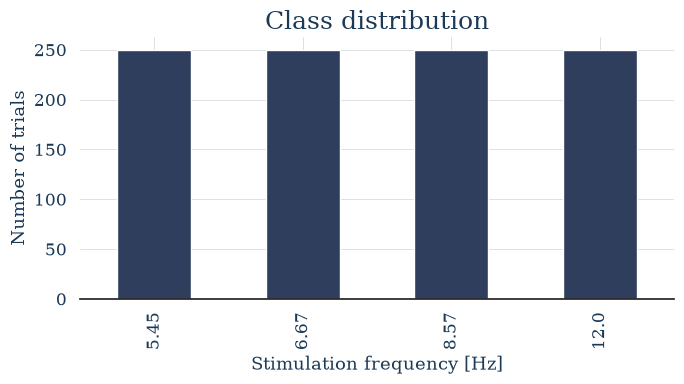

In [16]:
label_counts = pd.Series(labels_float).value_counts().sort_index()
print(label_counts)

ax = label_counts.plot(kind="bar", figsize=(7, 4))
ax.set_xlabel("Stimulation frequency [Hz]")
ax.set_ylabel("Number of trials")
ax.set_title("Class distribution")
plt.tight_layout()
plt.show()
def generate_single_harmonic_reference(
    freq: float,
    harmonic: int,
    n_samples: int,
    fs: int,
) -> np.ndarray:
    t = np.arange(n_samples) / fs

    return np.vstack([
        np.sin(2 * np.pi * harmonic * freq * t),
        np.cos(2 * np.pi * harmonic * freq * t),
    ])

# 6. Channel selection

## 6.1 Why posterior channels?

SSVEP responses are visually evoked and are usually strongest over posterior visual areas. Therefore, this notebook focuses on an occipito-parietal subset available in Lee2019_SSVEP:

```text
PO9, PO3, POz, PO4, PO10, O1, Oz, O2
```

The term **posterior channels** is used because the selected set contains both parieto-occipital and occipital channels.

## 6.2 Selected channels


In [17]:
print("Posterior channels:", POSTERIOR_CHANNELS)
print("Posterior channel indices:", POSTERIOR_CHANNEL_INDICES)

Posterior channels: ['PO9', 'PO3', 'POz', 'PO4', 'PO10', 'O1', 'Oz', 'O2']
Posterior channel indices: [27, 60, 43, 61, 31, 28, 29, 30]


## 6.3 Create posterior signal arrays

In [18]:
X_posterior_raw = X[:, POSTERIOR_CHANNEL_INDICES, :]

print("Raw posterior signal shape:", X_posterior_raw.shape)

Raw posterior signal shape: (1000, 8, 1000)


# 7. Preprocessing

## 7.1 Band-pass filtering rationale

A 5–45 Hz band-pass filter is used for spectral visualization and local-SNR analysis. This range removes slow drifts and high-frequency noise while preserving the stimulation frequencies and their first few harmonics.

Zero-phase filtering is used to avoid phase shifts in the filtered signal.

## 7.2 Apply preprocessing

In [19]:
X_filtered = filter_eeg_trials(
    X,
    lowcut=5.0,
    highcut=45.0,
    fs=FS,
    order=4,
    filter_type="cheby",
)

X_posterior_filtered = X_filtered[:, POSTERIOR_CHANNEL_INDICES, :]

print("Filtered posterior signal shape:", X_posterior_filtered.shape)

Filtered posterior signal shape: (1000, 8, 1000)


## 7.3 Raw vs filtered signal usage

The MOABB SSVEP paradigm already applies a 4–45 Hz band-pass filter and resamples to 250 Hz (see Section 5.1–5.2).

In this notebook:

- `X_posterior_filtered` (from Section 7.2) applies an *additional* 5–45 Hz Chebyshev filter for visualization and local-SNR baseline only.
- `X_posterior_raw` (from Section 6.3) is used for CCA/FBCCA functions to avoid double filtering — these methods apply their own filtering internally where needed.
- Filter-bank methods (FBCCA, FB-TRCA) apply sub-band decomposition as part of the algorithm and are not subject to double filtering.

This avoids accidental double filtering and makes model comparisons clearer.



# Baseline compatibility layer

The advanced comparison sections reference the original SNR / CCA / FBCCA 4-class
baselines. The minimal definitions and baseline calculations are included here so this
notebook remains standalone; the detailed exploratory plots stay in the simple notebook.


In [25]:
def build_snr_dataframe(
    trials: np.ndarray,
    true_labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata: pd.DataFrame | None = None,
    noise_width: int = 2,
    skip_width: int = 1,
) -> pd.DataFrame:
    """Builds a trial-level SNR table for all target frequencies."""
    rows = []

    for trial_idx, trial in enumerate(trials):
        freqs, trial_psd = compute_trial_mean_psd(
            trial=trial,
            fs=fs,
            nperseg=trial.shape[1],
        )

        result = {
            "trial": trial_idx,
            "true_label": float(true_labels[trial_idx]),
        }
        result = add_metadata_to_result(result, metadata, trial_idx)

        for target_freq in target_freqs:
            snr, snr_db = compute_snr_at_freq(
                freqs=freqs,
                psd=trial_psd,
                target_freq=float(target_freq),
                noise_width=noise_width,
                skip_width=skip_width,
            )
            result[f"SNR_{target_freq:.2f}"] = snr
            result[f"SNRdB_{target_freq:.2f}"] = snr_db

        rows.append(result)

    snr_df = pd.DataFrame(rows)
    snr_columns = [f"SNR_{freq:.2f}" for freq in target_freqs]
    best_col = snr_df[snr_columns].idxmax(axis=1)

    snr_df["predicted_label"] = best_col.str.replace("SNR_", "", regex=False).astype(float)
    snr_df["correct"] = np.isclose(
        snr_df["true_label"].astype(float),
        snr_df["predicted_label"].astype(float),
        atol=0.01,
    )

    return snr_df


snr_df_4 = build_snr_dataframe(
    trials=X_posterior_filtered,
    true_labels=labels_float,
    target_freqs=TARGET_FREQS_ALL,
    fs=FS,
    metadata=metadata,
)

snr_df_4.head()

,trial,true_label,subject,session,run,SNR_5.45,SNRdB_5.45,SNR_6.67,SNRdB_6.67,SNR_8.57,SNRdB_8.57,SNR_12.00,SNRdB_12.00,predicted_label,correct
0,0,6.67,1,1,1train,1.218713,0.859015,3.842746,5.846417,1.472099,1.679369,3.884680,5.893553,12.00,False
1,1,5.45,1,1,1train,3.778093,5.772727,0.038680,-14.125120,1.612716,2.075579,0.670480,-1.736141,5.45,True
2,2,5.45,1,1,1train,1.265345,1.022091,0.355063,-4.496940,0.897168,-0.471264,0.572276,-2.423947,5.45,True
3,3,8.57,1,1,1train,1.238981,0.930647,1.211833,0.834426,2.229877,3.482809,0.465082,-3.324705,8.57,True
4,4,8.57,1,1,1train,0.681406,-1.665938,0.126229,-8.988396,0.640874,-1.932275,5.644749,7.516446,12.00,False


In [26]:
print_metrics(snr_df_4, "SNR baseline 4-class")
print("Per-class accuracy:")
print(per_class_accuracy(snr_df_4))

SNR baseline 4-class accuracy: 61.90%
SNR baseline 4-class balanced accuracy: 61.90%

              precision    recall  f1-score   support

       12.00      0.685     0.712     0.698       250
        5.45      0.563     0.628     0.594       250
        6.67      0.620     0.508     0.558       250
        8.57      0.613     0.628     0.621       250

    accuracy                          0.619      1000
   macro avg      0.620     0.619     0.618      1000
weighted avg      0.620     0.619     0.618      1000

Per-class accuracy:
true_label
5.45     0.628
6.67     0.508
8.57     0.628
12.00    0.712
Name: correct, dtype: float64


In [28]:
def cca_predict(
    trials: np.ndarray,
    true_labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    filter_band: tuple[float, float] | None = None,
    n_harmonics: int = 3,
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
    metadata: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Predicts SSVEP classes using standard CCA."""
    start_sample = int(trim_start_sec * fs)
    trials_used = trials[:, :, start_sample:] if start_sample > 0 else trials
    n_samples = trials_used.shape[2]

    references = {
        float(freq): generate_reference_signals(
            freq=float(freq),
            n_samples=n_samples,
            fs=fs,
            n_harmonics=n_harmonics,
        )
        for freq in target_freqs
    }

    results = []

    for trial_idx, trial in enumerate(trials_used):
        if filter_band is not None:
            lowcut, highcut = filter_band
            trial_for_cca = filter_trial(
                trial=trial,
                lowcut=lowcut,
                highcut=highcut,
                fs=fs,
                order=filter_order,
                filter_type="butter",
            )
        else:
            trial_for_cca = trial

        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            rho = get_cca_correlation(
                data=trial_for_cca,
                ref=references[target_freq],
            )
            class_scores[target_freq] = rho

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(true_labels[trial_idx]),
            "predicted_label": float(predicted_freq),
            "cca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata, trial_idx)

        for freq, score in class_scores.items():
            result[f"CCA_{freq:.2f}"] = float(score)

        results.append(result)

    cca_df = pd.DataFrame(results)
    cca_df["correct"] = np.isclose(
        cca_df["true_label"].astype(float),
        cca_df["predicted_label"].astype(float),
        atol=0.01,
    )

    return cca_df

In [29]:
cca_df_4 = cca_predict(
    trials=X_posterior_raw,
    true_labels=labels_float,
    target_freqs=TARGET_FREQS_ALL,
    fs=FS,
    filter_band=(5, 45),
    n_harmonics=3,
    trim_start_sec=0.0,
    metadata=metadata,
)

print_metrics(cca_df_4, "CCA 4-class")
print("Per-class accuracy:")
print(per_class_accuracy(cca_df_4))

CCA 4-class accuracy: 95.10%
CCA 4-class balanced accuracy: 95.10%

              precision    recall  f1-score   support

       12.00      0.991     0.904     0.946       250
        5.45      0.925     0.980     0.951       250
        6.67      0.992     0.944     0.967       250
        8.57      0.907     0.976     0.940       250

    accuracy                          0.951      1000
   macro avg      0.954     0.951     0.951      1000
weighted avg      0.954     0.951     0.951      1000

Per-class accuracy:
true_label
5.45     0.980
6.67     0.944
8.57     0.976
12.00    0.904
Name: correct, dtype: float64


In [33]:
def fbcca_predict(
    trials: np.ndarray,
    true_labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    filter_bands: list[tuple[float, float]] | None = None,
    n_harmonics: int = 3,
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
    metadata: pd.DataFrame | None = None,
    weights: np.ndarray | None = None,
) -> pd.DataFrame:
    """Predicts SSVEP classes using simplified FBCCA."""
    if filter_bands is None:
        filter_bands = [(5, 45), (10, 45), (15, 45)]

    start_sample = int(trim_start_sec * fs)
    trials_used = trials[:, :, start_sample:] if start_sample > 0 else trials
    n_samples = trials_used.shape[2]

    references = {
        float(freq): generate_reference_signals(
            freq=float(freq),
            n_samples=n_samples,
            fs=fs,
            n_harmonics=n_harmonics,
        )
        for freq in target_freqs
    }

    if weights is None:
        weights = np.array([
            (band_idx + 1) ** (-1.25) + 0.25
            for band_idx in range(len(filter_bands))
        ])
    else:
        weights = np.asarray(weights)

    results = []

    for trial_idx, trial in enumerate(trials_used):
        filtered_subbands = []

        # Filtering does not depend on target frequency, so it is done once per subband.
        for lowcut, highcut in filter_bands:
            filtered_trial = filter_trial(
                trial=trial,
                lowcut=lowcut,
                highcut=highcut,
                fs=fs,
                order=filter_order,
                filter_type="butter",
            )
            filtered_subbands.append(filtered_trial)

        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            subband_scores = []

            for filtered_trial in filtered_subbands:
                rho = get_cca_correlation(
                    data=filtered_trial,
                    ref=references[target_freq],
                )
                subband_scores.append(rho ** 2)

            final_score = np.dot(np.array(subband_scores), weights[:len(subband_scores)])
            class_scores[target_freq] = final_score

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(true_labels[trial_idx]),
            "predicted_label": float(predicted_freq),
            "fbcca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata, trial_idx)

        for freq, score in class_scores.items():
            result[f"FBCCA_{freq:.2f}"] = float(score)

        results.append(result)

    fbcca_df = pd.DataFrame(results)
    fbcca_df["correct"] = np.isclose(
        fbcca_df["true_label"].astype(float),
        fbcca_df["predicted_label"].astype(float),
        atol=0.01,
    )

    return fbcca_df

In [34]:
DEFAULT_FBCCA_BANDS = [(5, 45), (10, 45), (15, 45)]

fbcca_df_4 = fbcca_predict(
    trials=X_posterior_raw,
    true_labels=labels_float,
    target_freqs=TARGET_FREQS_ALL,
    fs=FS,
    filter_bands=DEFAULT_FBCCA_BANDS,
    n_harmonics=3,
    trim_start_sec=0.0,
    metadata=metadata,
)

print_metrics(fbcca_df_4, "FBCCA 4-class")
print("Per-class accuracy:")
print(per_class_accuracy(fbcca_df_4))

FBCCA 4-class accuracy: 97.60%
FBCCA 4-class balanced accuracy: 97.60%

              precision    recall  f1-score   support

       12.00      0.988     0.956     0.972       250
        5.45      0.954     0.992     0.973       250
        6.67      0.992     0.976     0.984       250
        8.57      0.972     0.980     0.976       250

    accuracy                          0.976      1000
   macro avg      0.976     0.976     0.976      1000
weighted avg      0.976     0.976     0.976      1000

Per-class accuracy:
true_label
5.45     0.992
6.67     0.976
8.57     0.980
12.00    0.956
Name: correct, dtype: float64


# 13. Advanced supervised SSVEP methods — Educational Implementation (v4 style)

⚠️ **WAŻNE**: Ta sekcja zawiera **przezroczyste, edukacyjne implementacje** algorytmów SSVEP, ale implementacja TRCA/eTRCA różni się od wersji "reference-aligned" w sekcji 21.2. Przed publikacją porównaj wyniki z sekcją 21.2, która używa poprawionej scoring.

The previous sections used methods that can work without subject-specific calibration: SNR, standard CCA and FBCCA. This section adds more advanced methods that use either narrower frequency-domain assumptions or training data from the same dataset.

Implemented methods:

- **Narrow-band CCA / NB-CCA** — CCA applied around the fundamental frequency and selected harmonics.
- **IT-CCA** — individual-template CCA using class templates averaged from training trials.
- **Simplified eCCA** — an extended CCA-style score combining sine/cosine references and individual templates.
- **MsetCCA-inspired method** — multi-set CCA-inspired class reference learning from training trials.
- **TRCA** — task-related component analysis using class-specific spatial filters.
- **eTRCA** — ensemble TRCA using filters learned for all classes.

Important methodological note: IT-CCA, eCCA, MsetCCA, TRCA and eTRCA use training data. Therefore, they are evaluated with stratified cross-validation to avoid training-test leakage. These implementations are educational and transparent; for publication-level benchmarking, see Section 21.2 for reference-aligned versions.


## 13.1 Advanced-method configuration

By default, this section evaluates the full 4-class Lee2019_SSVEP problem because the four frequencies correspond directly to the four directional commands. Reduced frequency subsets can still be evaluated as exploratory design experiments.


In [ ]:
# Advanced supervised methods configuration.

# Recommended default: full four-direction Lee2019_SSVEP problem.
ADVANCED_TARGET_FREQS = TARGET_FREQS_ALL.copy()

# Exploratory 3-class setup without 5.45 Hz.
# ADVANCED_TARGET_FREQS = [6.67, 8.57, 12.00]

# Exploratory 2-class setup.
# ADVANCED_TARGET_FREQS = [8.57, 12.00]

ADVANCED_N_SPLITS = 5
ADVANCED_FILTER_BAND = (5, 45)
ADVANCED_N_HARMONICS = 3
ADVANCED_TRIM_START_SEC = 0.0

X_advanced, labels_advanced, metadata_advanced = select_frequency_subset(
    trials=X_posterior_raw,
    labels=labels,
    metadata=metadata,
    selected_freqs=ADVANCED_TARGET_FREQS,
)

print("Advanced target frequencies:", ADVANCED_TARGET_FREQS)
print("X_advanced shape:", X_advanced.shape)
print("Class distribution:")
print(pd.Series(labels_advanced).value_counts().sort_index())


Advanced target frequencies: [5.45, 6.67, 8.57, 12.0]
X_advanced shape: (1000, 8, 1000)
Class distribution:
5.45     250
6.67     250
8.57     250
12.00    250
Name: count, dtype: int64


## 13.2 Cross-validation and template utilities

The following helper functions are shared by all training-based methods. They implement a consistent stratified cross-validation protocol and class-template construction.


In [ ]:
def trim_trials(
    trials: np.ndarray,
    fs: int,
    trim_start_sec: float = 0.0,
) -> np.ndarray:
    """Removes the first part of each trial when trim_start_sec > 0."""
    start_sample = int(trim_start_sec * fs)
    return trials[:, :, start_sample:] if start_sample > 0 else trials


def preprocess_trials_for_model(
    trials: np.ndarray,
    fs: int,
    filter_band: tuple[float, float] | None = None,
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
) -> np.ndarray:
    """Trims trials and optionally applies one Butterworth band-pass filter to each trial."""
    trials_used = trim_trials(trials, fs=fs, trim_start_sec=trim_start_sec)

    if filter_band is None:
        return np.asarray(trials_used, dtype=float)

    lowcut, highcut = filter_band
    filtered = np.zeros_like(trials_used, dtype=float)

    for trial_idx, trial in enumerate(trials_used):
        filtered[trial_idx] = filter_trial(
            trial=trial,
            lowcut=lowcut,
            highcut=highcut,
            fs=fs,
            order=filter_order,
            filter_type="butter",
        )

    return filtered


def build_class_templates(
    trials: np.ndarray,
    labels: np.ndarray,
    target_freqs: list[float],
) -> dict[float, np.ndarray]:
    """Builds one average EEG template per class from training trials."""
    labels_float = labels.astype(float)
    templates = {}

    for freq in target_freqs:
        freq = float(freq)
        class_trials = trials[np.isclose(labels_float, freq, atol=0.01)]

        if class_trials.shape[0] == 0:
            raise ValueError(f"No training trials found for frequency {freq} Hz.")

        templates[freq] = class_trials.mean(axis=0)

    return templates


def safe_corrcoef(x: np.ndarray, y: np.ndarray) -> float:
    """Returns Pearson correlation for two 1-D arrays; returns 0 for degenerate inputs."""
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()

    if x.size != y.size:
        raise ValueError("x and y must have the same length.")
    if np.std(x) == 0 or np.std(y) == 0:
        return 0.0

    corr = np.corrcoef(x, y)[0, 1]
    return 0.0 if np.isnan(corr) else float(corr)


def make_cv_labels(labels: np.ndarray) -> np.ndarray:
    """Converts float stimulation frequencies to categorical labels for StratifiedKFold."""
    return format_frequency_labels(labels).to_numpy()


def call_method_with_supported_args(method_fn, **kwargs):
    """Calls a train/test method using only keyword arguments supported by its signature.

    This prevents errors such as:
    TypeError: <method>() got an unexpected keyword argument 'metadata'
    when different advanced methods use slightly different parameter names.
    """
    import inspect

    signature = inspect.signature(method_fn)
    supported_kwargs = {
        key: value
        for key, value in kwargs.items()
        if key in signature.parameters
    }
    return method_fn(**supported_kwargs)


def evaluate_cv_template_method(
    method_fn,
    trials: np.ndarray,
    labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata: pd.DataFrame | None = None,
    n_splits: int = 5,
    random_state: int = RANDOM_STATE,
    **method_kwargs,
) -> pd.DataFrame:
    """Evaluates a train/test SSVEP method with stratified K-fold cross-validation.

    Frequency labels are stored as floats in this project, e.g. 5.45, 6.67, 8.57 and 12.00.
    sklearn's StratifiedKFold treats non-integer floats as continuous targets, so labels
    are converted to categorical strings for splitting. The original float labels are
    still passed to the train/test methods because they represent actual frequencies.
    """
    labels_float = np.asarray(labels, dtype=float)
    labels_cv = make_cv_labels(labels_float)

    class_counts = pd.Series(labels_cv).value_counts()
    min_class_count = int(class_counts.min())
    effective_n_splits = min(int(n_splits), min_class_count)

    if effective_n_splits < 2:
        raise ValueError(
            "At least two trials per selected class are required for stratified CV."
        )

    if effective_n_splits != n_splits:
        print(
            f"Requested n_splits={n_splits}, but the smallest class has only "
            f"{min_class_count} trials. Using n_splits={effective_n_splits}."
        )

    metadata_reset = metadata.reset_index(drop=True) if metadata is not None else None

    skf = StratifiedKFold(
        n_splits=effective_n_splits,
        shuffle=True,
        random_state=random_state,
    )

    fold_results = []
    X_dummy = np.zeros(len(labels_cv))

    for fold_idx, (train_idx, test_idx) in enumerate(
        skf.split(X_dummy, labels_cv),
        start=1,
    ):
        metadata_test = (
            metadata_reset.iloc[test_idx].reset_index(drop=True)
            if metadata_reset is not None
            else None
        )

        fold_df = call_method_with_supported_args(
            method_fn,
            X_train=trials[train_idx],
            y_train=labels_float[train_idx],
            X_test=trials[test_idx],
            y_test=labels_float[test_idx],
            target_freqs=target_freqs,
            fs=fs,
            metadata_test=metadata_test,
            metadata=metadata_test,
            **method_kwargs,
        )

        fold_df.insert(0, "fold", fold_idx)
        fold_df.insert(1, "trial_global_index", test_idx)
        fold_results.append(fold_df)

    return pd.concat(fold_results, ignore_index=True)


## 13.2b Subject-dependent cross-validation (fix)

`evaluate_cv_template_method` above (unchanged, kept for comparison) pools trials from
all subjects before doing `StratifiedKFold`. For template/filter-based methods this means
a class "template" or TRCA spatial filter can be learned from a training fold that mixes
different people, which dilutes or destroys the trial-to-trial reproducibility these
methods rely on.

`evaluate_cv_template_method_per_subject` below fixes this: it loops over each subject,
runs stratified K-fold **only on that subject's own trials**, and concatenates the
per-subject fold results. This matches the standard "subject-dependent" (a.k.a.
within-subject calibration) evaluation protocol used in the SSVEP literature for
TRCA/eTRCA/IT-CCA/MsetCCA benchmarks. It requires `metadata` with a `subject` column,
which is already attached throughout this notebook.


In [ ]:
def evaluate_cv_template_method_per_subject(
    method_fn,
    trials: np.ndarray,
    labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata: pd.DataFrame | None = None,
    n_splits: int = 5,
    random_state: int = RANDOM_STATE,
    min_trials_per_class: int = 2,
    verbose: bool = True,
    **method_kwargs,
) -> pd.DataFrame:
    """Evaluates a train/test SSVEP method with subject-dependent stratified K-fold CV.

    Unlike `evaluate_cv_template_method`, this function never mixes trials from different
    subjects between train and test, and never learns a template/filter from more than one
    subject's data. Each subject is calibrated and evaluated using only their own trials,
    matching the standard subject-dependent SSVEP benchmarking protocol.

    Subjects with fewer than `min_trials_per_class` trials in their smallest class are
    skipped (with a warning) rather than causing a hard failure, since CV needs at least
    two trials per class per fold.
    """
    if metadata is None or "subject" not in metadata.columns:
        raise ValueError(
            "metadata with a 'subject' column is required for per-subject CV."
        )

    labels_float = np.asarray(labels, dtype=float)
    metadata_reset = metadata.reset_index(drop=True)
    subjects = metadata_reset["subject"].to_numpy()

    fold_results = []

    for subject_id in np.unique(subjects):
        subject_mask = subjects == subject_id
        X_subject = trials[subject_mask]
        y_subject = labels_float[subject_mask]
        meta_subject = metadata_reset.loc[subject_mask].reset_index(drop=True)

        labels_cv = make_cv_labels(y_subject)
        class_counts = pd.Series(labels_cv).value_counts()
        min_class_count = int(class_counts.min()) if len(class_counts) > 0 else 0

        if min_class_count < min_trials_per_class:
            if verbose:
                print(
                    f"Skipping subject {subject_id}: smallest class has only "
                    f"{min_class_count} trial(s), need at least {min_trials_per_class}."
                )
            continue

        effective_n_splits = min(int(n_splits), min_class_count)
        if effective_n_splits < 2:
            if verbose:
                print(f"Skipping subject {subject_id}: not enough trials for CV.")
            continue

        skf = StratifiedKFold(
            n_splits=effective_n_splits,
            shuffle=True,
            random_state=random_state,
        )
        X_dummy = np.zeros(len(labels_cv))

        for fold_idx, (train_idx, test_idx) in enumerate(
            skf.split(X_dummy, labels_cv),
            start=1,
        ):
            metadata_test = meta_subject.iloc[test_idx].reset_index(drop=True)

            fold_df = call_method_with_supported_args(
                method_fn,
                X_train=X_subject[train_idx],
                y_train=y_subject[train_idx],
                X_test=X_subject[test_idx],
                y_test=y_subject[test_idx],
                target_freqs=target_freqs,
                fs=fs,
                metadata_test=metadata_test,
                metadata=metadata_test,
                **method_kwargs,
            )

            # metadata_test already carries a "subject" column (added inside
            # method_fn via add_metadata_to_result), so assign instead of using
            # .insert() here to avoid a duplicate-column error; assignment
            # overwrites the column if present and creates it if not.
            fold_df["subject"] = subject_id
            fold_df["fold"] = fold_idx
            leading_cols = [c for c in ["subject", "fold"] if c in fold_df.columns]
            other_cols = [c for c in fold_df.columns if c not in leading_cols]
            fold_df = fold_df[leading_cols + other_cols]
            fold_results.append(fold_df)

    if not fold_results:
        raise ValueError("No subject produced any valid CV fold; check class counts.")

    return pd.concat(fold_results, ignore_index=True)


## 13.3 Narrow-band CCA / NB-CCA

Narrow-band CCA tests a stricter spectral assumption than standard CCA. Instead of filtering the entire broad SSVEP band, it applies CCA in narrow bands around the expected frequency components: `f`, `2f`, `3f`, etc. This may help when broad-band CCA includes too much unrelated EEG background activity.

This method does not use training data, but it is included here because it was one of the proposed extensions for improving the final result.


In [ ]:
def narrow_band_cca_predict(
    trials: np.ndarray,
    true_labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    harmonics: list[int] | None = None,
    band_half_width: float = 1.0,
    low_limit: float = 5.0,
    high_limit: float = 45.0,
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
    metadata: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Predicts SSVEP class using narrow-band CCA around each harmonic.
    
    POPRAWKA v5.1: Teraz prawidłowo dodaje metadata do wyników.
    """
    if harmonics is None:
        harmonics = [1, 2, 3]

    trials_used = trim_trials(trials, fs=fs, trim_start_sec=trim_start_sec)
    n_samples = trials_used.shape[2]
    nyq = 0.5 * fs

    harmonic_weights = np.array([1 / h for h in harmonics], dtype=float)

    results = []

    for trial_idx, trial in enumerate(trials_used):
        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            target_scores = []
            target_weights = []

            for weight, harmonic in zip(harmonic_weights, harmonics):
                center_freq = harmonic * target_freq
                lowcut = max(low_limit, center_freq - band_half_width)
                highcut = min(high_limit, center_freq + band_half_width)

                if lowcut <= 0 or highcut >= nyq or lowcut >= highcut:
                    continue

                filtered_trial = filter_trial(
                    trial=trial,
                    lowcut=lowcut,
                    highcut=highcut,
                    fs=fs,
                    order=filter_order,
                    filter_type="butter",
                )

                ref = generate_single_harmonic_reference(
                    freq=target_freq,
                    harmonic=harmonic,
                    n_samples=n_samples,
                    fs=fs,
                )

                rho = get_cca_correlation(filtered_trial, ref)
                target_scores.append(rho ** 2)
                target_weights.append(weight)

            if len(target_scores) == 0:
                class_scores[target_freq] = 0.0
            else:
                class_scores[target_freq] = float(
                    np.dot(np.array(target_scores), np.array(target_weights))
                )

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(true_labels[trial_idx]),
            "predicted_label": float(predicted_freq),
            "nbcca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata, trial_idx)
        results.append(result)

    df = pd.DataFrame(results)
    df["correct"] = np.isclose(
        df["true_label"].astype(float),
        df["predicted_label"].astype(float),
        atol=0.01,
    )
    return df


In [ ]:
nbcca_df_advanced = narrow_band_cca_predict(
    trials=X_advanced,
    true_labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    harmonics=[1, 2, 3],
    band_half_width=1.0,
    low_limit=5.0,
    high_limit=45.0,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
    metadata=metadata_advanced,
)

print_metrics(nbcca_df_advanced, "Narrow-band CCA")
per_class_accuracy(nbcca_df_advanced)


Narrow-band CCA accuracy: 93.10%
Narrow-band CCA balanced accuracy: 93.10%

              precision    recall  f1-score   support

       12.00      0.966     0.904     0.934       250
        5.45      0.854     0.984     0.914       250
        6.67      0.966     0.916     0.940       250
        8.57      0.954     0.920     0.937       250

    accuracy                          0.931      1000
   macro avg      0.935     0.931     0.931      1000
weighted avg      0.935     0.931     0.931      1000



true_label
5.45     0.984
6.67     0.916
8.57     0.920
12.00    0.904
Name: correct, dtype: float64

## 13.4 IT-CCA: individual-template CCA

IT-CCA replaces purely sinusoidal references with individual EEG templates estimated from training trials. For each class, the training trials are averaged into a class template. During prediction, the test trial is compared with each template using CCA.

This method is supervised/calibrated: it can use information about the individual structure of SSVEP responses, but it requires training data from the subject or dataset.


In [ ]:
def itcca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
    filter_band: tuple[float, float] | None = (5, 45),
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
) -> pd.DataFrame:
    """Train/test prediction using individual-template CCA."""
    X_train_p = preprocess_trials_for_model(
        X_train, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )
    X_test_p = preprocess_trials_for_model(
        X_test, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )

    templates = build_class_templates(X_train_p, y_train, target_freqs)

    results = []

    for trial_idx, trial in enumerate(X_test_p):
        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            rho = get_cca_correlation(trial, templates[target_freq])
            class_scores[target_freq] = rho ** 2

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(predicted_freq),
            "itcca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata_test, trial_idx)
        results.append(result)

    df = pd.DataFrame(results)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


In [ ]:
itcca_df_advanced = evaluate_cv_template_method(
    method_fn=itcca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(itcca_df_advanced, "IT-CCA")
per_class_accuracy(itcca_df_advanced)


IT-CCA accuracy: 96.10%
IT-CCA balanced accuracy: 96.10%

              precision    recall  f1-score   support

       12.00      0.956     0.952     0.954       250
        5.45      0.972     0.964     0.968       250
        6.67      0.992     0.952     0.971       250
        8.57      0.928     0.976     0.951       250

    accuracy                          0.961      1000
   macro avg      0.962     0.961     0.961      1000
weighted avg      0.962     0.961     0.961      1000



true_label
5.45     0.964
6.67     0.952
8.57     0.976
12.00    0.952
Name: correct, dtype: float64

### 13.4b IT-CCA — subject-dependent calibration

The same method is evaluated with `evaluate_cv_template_method_per_subject` instead of the subject-mixed version above. This allows a direct comparison between pooled-subject and within-subject calibration protocols without changing the underlying classifier.


In [ ]:
itcca_df_advanced_subjectcv = evaluate_cv_template_method_per_subject(
    method_fn=itcca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(itcca_df_advanced_subjectcv, "IT-CCA (subject-dependent)")
per_class_accuracy(itcca_df_advanced_subjectcv)


IT-CCA (subject-dependent) accuracy: 96.60%
IT-CCA (subject-dependent) balanced accuracy: 96.60%

              precision    recall  f1-score   support

       12.00      0.956     0.952     0.954       250
        5.45      0.968     0.980     0.974       250
        6.67      0.980     0.968     0.974       250
        8.57      0.960     0.964     0.962       250

    accuracy                          0.966      1000
   macro avg      0.966     0.966     0.966      1000
weighted avg      0.966     0.966     0.966      1000



true_label
5.45     0.980
6.67     0.968
8.57     0.964
12.00    0.952
Name: correct, dtype: float64

## 13.5 Simplified eCCA: extended CCA-style scoring

Extended CCA methods combine sinusoidal reference information with individual EEG templates. The exact variants differ across papers and toolboxes. In this notebook, a transparent eCCA-style score is implemented as a combination of three CCA terms:

1. test EEG vs sinusoidal reference,
2. test EEG vs class template,
3. class template vs sinusoidal reference.

This is useful as an interpretable extension between standard CCA and fully supervised template methods. Treat it as a simplified educational implementation rather than a drop-in replacement for every published eCCA variant.


In [ ]:
def ecca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
    filter_band: tuple[float, float] | None = (5, 45),
    n_harmonics: int = 3,
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
) -> pd.DataFrame:
    """Train/test prediction using a simplified extended CCA-style score."""
    X_train_p = preprocess_trials_for_model(
        X_train, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )
    X_test_p = preprocess_trials_for_model(
        X_test, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )

    n_samples = X_test_p.shape[2]
    templates = build_class_templates(X_train_p, y_train, target_freqs)

    references = {
        float(freq): generate_reference_signals(
            freq=float(freq),
            n_samples=n_samples,
            fs=fs,
            n_harmonics=n_harmonics,
        )
        for freq in target_freqs
    }

    results = []

    for trial_idx, trial in enumerate(X_test_p):
        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            template = templates[target_freq]
            ref = references[target_freq]

            rho_test_ref = get_cca_correlation(trial, ref)
            rho_test_template = get_cca_correlation(trial, template)
            rho_template_ref = get_cca_correlation(template, ref)

            score = (
                rho_test_ref ** 2
                + rho_test_template ** 2
                + rho_template_ref ** 2
            )
            class_scores[target_freq] = float(score)

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(predicted_freq),
            "ecca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata_test, trial_idx)
        results.append(result)

    df = pd.DataFrame(results)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


In [ ]:
ecca_df_advanced = evaluate_cv_template_method(
    method_fn=ecca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    n_harmonics=ADVANCED_N_HARMONICS,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(ecca_df_advanced, "Simplified eCCA")
per_class_accuracy(ecca_df_advanced)


Simplified eCCA accuracy: 96.40%
Simplified eCCA balanced accuracy: 96.40%

              precision    recall  f1-score   support

       12.00      0.983     0.940     0.961       250
        5.45      0.957     0.972     0.964       250
        6.67      0.992     0.960     0.976       250
        8.57      0.928     0.984     0.955       250

    accuracy                          0.964      1000
   macro avg      0.965     0.964     0.964      1000
weighted avg      0.965     0.964     0.964      1000



true_label
5.45     0.972
6.67     0.960
8.57     0.984
12.00    0.940
Name: correct, dtype: float64

### 13.5b Simplified eCCA — subject-dependent calibration (fixed)


In [ ]:
ecca_df_advanced_subjectcv = evaluate_cv_template_method_per_subject(
    method_fn=ecca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    n_harmonics=ADVANCED_N_HARMONICS,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(ecca_df_advanced_subjectcv, "Simplified eCCA (subject-dependent)")
per_class_accuracy(ecca_df_advanced_subjectcv)


Simplified eCCA (subject-dependent) accuracy: 95.20%
Simplified eCCA (subject-dependent) balanced accuracy: 95.20%

              precision    recall  f1-score   support

       12.00      0.974     0.904     0.938       250
        5.45      0.949     0.976     0.963       250
        6.67      0.987     0.936     0.961       250
        8.57      0.905     0.992     0.947       250

    accuracy                          0.952      1000
   macro avg      0.954     0.952     0.952      1000
weighted avg      0.954     0.952     0.952      1000



true_label
5.45     0.976
6.67     0.936
8.57     0.992
12.00    0.904
Name: correct, dtype: float64

## 13.6 MsetCCA-inspired class reference learning

Multi-set CCA learns reference information from multiple training trials rather than using only ideal sine/cosine signals. A full MsetCCA implementation can become computationally heavy when each class has many trials, because the block covariance problem grows with the number of training trials.

The implementation below is a compact MsetCCA-inspired version:

- a limited number of training trials is selected for each class,
- a block covariance problem is solved to find trial-specific projections,
- projected training trials are averaged into a 1-D class reference,
- test EEG is compared with each learned class reference using CCA.

This gives a practical notebook-level demonstration of the idea without turning the EDA into a heavy algorithm-engineering project.


In [ ]:
def solve_generalized_eigen_max(
    A: np.ndarray,
    B: np.ndarray,
    reg: float = 1e-6,
) -> np.ndarray:
    """Solves a generalized eigenproblem and returns the eigenvector with largest eigenvalue."""
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)

    A = 0.5 * (A + A.T)
    B = 0.5 * (B + B.T)
    B = B + reg * np.eye(B.shape[0])

    try:
        eigvals, eigvecs = eigh(A, B)
    except Exception:
        eigvals, eigvecs = np.linalg.eig(np.linalg.pinv(B) @ A)

    best_idx = int(np.argmax(np.real(eigvals)))
    return np.real(eigvecs[:, best_idx])


def learn_msetcca_reference(
    class_trials: np.ndarray,
    max_trials: int = 20,
    random_state: int = RANDOM_STATE,
    reg: float = 1e-6,
) -> np.ndarray:
    """Learns a 1-D class reference using a compact MsetCCA-inspired block covariance problem."""
    rng = np.random.default_rng(random_state)
    trials = np.asarray(class_trials, dtype=float)

    if trials.shape[0] > max_trials:
        selected = rng.choice(trials.shape[0], size=max_trials, replace=False)
        trials = trials[np.sort(selected)]

    # Trial-wise channel centering.
    trials = trials - trials.mean(axis=2, keepdims=True)

    n_trials, n_channels, n_samples = trials.shape
    dim = n_trials * n_channels

    A = np.zeros((dim, dim), dtype=float)  # inter-set covariance
    B = np.zeros((dim, dim), dtype=float)  # block-diagonal within-set covariance

    for i in range(n_trials):
        Xi = trials[i]
        i0 = i * n_channels
        i1 = (i + 1) * n_channels

        B[i0:i1, i0:i1] = Xi @ Xi.T / max(n_samples - 1, 1)

        for j in range(n_trials):
            if i == j:
                continue

            Xj = trials[j]
            j0 = j * n_channels
            j1 = (j + 1) * n_channels
            A[i0:i1, j0:j1] = Xi @ Xj.T / max(n_samples - 1, 1)

    v = solve_generalized_eigen_max(A, B, reg=reg)
    W = v.reshape(n_trials, n_channels)

    projected_trials = np.array([
        W[i] @ trials[i]
        for i in range(n_trials)
    ])

    reference = projected_trials.mean(axis=0)
    return reference.reshape(1, -1)


def msetcca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
    filter_band: tuple[float, float] | None = (5, 45),
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
    max_trials_per_class: int = 20,
) -> pd.DataFrame:
    """Train/test prediction using compact MsetCCA-inspired learned references."""
    X_train_p = preprocess_trials_for_model(
        X_train, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )
    X_test_p = preprocess_trials_for_model(
        X_test, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )

    y_train = y_train.astype(float)
    references = {}

    for freq in target_freqs:
        freq = float(freq)
        class_trials = X_train_p[np.isclose(y_train, freq, atol=0.01)]
        references[freq] = learn_msetcca_reference(
            class_trials=class_trials,
            max_trials=max_trials_per_class,
            random_state=RANDOM_STATE,
        )

    results = []

    for trial_idx, trial in enumerate(X_test_p):
        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            rho = get_cca_correlation(trial, references[target_freq])
            class_scores[target_freq] = rho ** 2

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(predicted_freq),
            "msetcca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata_test, trial_idx)
        results.append(result)

    df = pd.DataFrame(results)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


In [ ]:
msetcca_df_advanced = evaluate_cv_template_method(
    method_fn=msetcca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
    max_trials_per_class=20,
)

print_metrics(msetcca_df_advanced, "MsetCCA-inspired")
per_class_accuracy(msetcca_df_advanced)


MsetCCA-inspired accuracy: 97.00%
MsetCCA-inspired balanced accuracy: 97.00%

              precision    recall  f1-score   support

       12.00      0.983     0.940     0.961       250
        5.45      0.954     0.992     0.973       250
        6.67      0.996     0.964     0.980       250
        8.57      0.950     0.984     0.967       250

    accuracy                          0.970      1000
   macro avg      0.971     0.970     0.970      1000
weighted avg      0.971     0.970     0.970      1000



true_label
5.45     0.992
6.67     0.964
8.57     0.984
12.00    0.940
Name: correct, dtype: float64

### 13.6b MsetCCA-inspired — subject-dependent calibration (fixed)


In [ ]:
msetcca_df_advanced_subjectcv = evaluate_cv_template_method_per_subject(
    method_fn=msetcca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
    max_trials_per_class=20,
)

print_metrics(msetcca_df_advanced_subjectcv, "MsetCCA-inspired (subject-dependent)")
per_class_accuracy(msetcca_df_advanced_subjectcv)


MsetCCA-inspired (subject-dependent) accuracy: 97.10%
MsetCCA-inspired (subject-dependent) balanced accuracy: 97.10%

              precision    recall  f1-score   support

       12.00      0.996     0.932     0.963       250
        5.45      0.943     0.992     0.967       250
        6.67      0.992     0.976     0.984       250
        8.57      0.957     0.984     0.970       250

    accuracy                          0.971      1000
   macro avg      0.972     0.971     0.971      1000
weighted avg      0.972     0.971     0.971      1000



true_label
5.45     0.992
6.67     0.976
8.57     0.984
12.00    0.932
Name: correct, dtype: float64

> **v5 note:** The implementation in this section is kept as the transparent educational TRCA version. A corrected/reference-like TRCA scoring implementation is added in Section 21.2 and should be preferred for the final robustness conclusions.

## 13.7 TRCA: task-related component analysis

TRCA learns class-specific spatial filters that maximize the reproducibility of EEG responses across training trials from the same class. This is well suited to SSVEP because the response to the same stimulus frequency should be phase-locked and repeatable across trials.

Compared with CCA/FBCCA, TRCA is not calibration-free. It needs training trials, but it can be much stronger when subject-specific calibration is available.


In [ ]:
def learn_trca_filter(
    class_trials: np.ndarray,
    reg: float = 1e-6,
) -> np.ndarray:
    """Learns one TRCA spatial filter for a single class."""
    trials = np.asarray(class_trials, dtype=float)
    trials = trials - trials.mean(axis=2, keepdims=True)

    n_trials, n_channels, _ = trials.shape

    S = np.zeros((n_channels, n_channels), dtype=float)
    Q = np.zeros((n_channels, n_channels), dtype=float)

    for i in range(n_trials):
        Xi = trials[i]
        Q += Xi @ Xi.T

        for j in range(n_trials):
            if i == j:
                continue
            Xj = trials[j]
            S += Xi @ Xj.T

    scale = np.trace(Q) / n_channels if np.trace(Q) > 0 else 1.0
    Q = Q + reg * scale * np.eye(n_channels)

    w = solve_generalized_eigen_max(S, Q, reg=reg)
    norm = np.linalg.norm(w)
    return w / norm if norm > 0 else w


def train_trca_model(
    X_train: np.ndarray,
    y_train: np.ndarray,
    target_freqs: list[float],
) -> tuple[dict[float, np.ndarray], dict[float, np.ndarray]]:
    """Learns TRCA templates and class-specific spatial filters."""
    templates = build_class_templates(X_train, y_train, target_freqs)
    filters = {}
    y_train = y_train.astype(float)

    for freq in target_freqs:
        freq = float(freq)
        class_trials = X_train[np.isclose(y_train, freq, atol=0.01)]
        filters[freq] = learn_trca_filter(class_trials)

    return templates, filters


def trca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
    filter_band: tuple[float, float] | None = (5, 45),
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
) -> pd.DataFrame:
    """Train/test prediction using TRCA."""
    X_train_p = preprocess_trials_for_model(
        X_train, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )
    X_test_p = preprocess_trials_for_model(
        X_test, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )

    templates, filters = train_trca_model(X_train_p, y_train, target_freqs)

    results = []

    for trial_idx, trial in enumerate(X_test_p):
        class_scores = {}

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            w = filters[target_freq]
            template = templates[target_freq]

            test_component = w @ trial
            template_component = w @ template
            rho = safe_corrcoef(test_component, template_component)
            class_scores[target_freq] = rho ** 2

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(predicted_freq),
            "trca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata_test, trial_idx)
        results.append(result)

    df = pd.DataFrame(results)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


In [ ]:
trca_df_advanced = evaluate_cv_template_method(
    method_fn=trca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(trca_df_advanced, "TRCA")
per_class_accuracy(trca_df_advanced)


TRCA accuracy: 96.50%
TRCA balanced accuracy: 96.50%

              precision    recall  f1-score   support

       12.00      0.996     0.912     0.952       250
        5.45      0.932     0.984     0.957       250
        6.67      0.984     0.984     0.984       250
        8.57      0.953     0.980     0.966       250

    accuracy                          0.965      1000
   macro avg      0.966     0.965     0.965      1000
weighted avg      0.966     0.965     0.965      1000



true_label
5.45     0.984
6.67     0.984
8.57     0.980
12.00    0.912
Name: correct, dtype: float64

### 13.7b TRCA — subject-dependent calibration

TRCA relies on trial-to-trial reproducibility within the same participant. Therefore, the subject-dependent evaluation below is methodologically more appropriate than pooling different subjects inside the same calibration folds.

The comparison should be interpreted empirically after the Lee2019_SSVEP run rather than assuming in advance that one protocol must produce higher accuracy.


In [ ]:
trca_df_advanced_subjectcv = evaluate_cv_template_method_per_subject(
    method_fn=trca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(trca_df_advanced_subjectcv, "TRCA (subject-dependent)")
per_class_accuracy(trca_df_advanced_subjectcv)


TRCA (subject-dependent) accuracy: 98.70%
TRCA (subject-dependent) balanced accuracy: 98.70%

              precision    recall  f1-score   support

       12.00      0.996     0.976     0.986       250
        5.45      0.962     1.000     0.980       250
        6.67      1.000     0.984     0.992       250
        8.57      0.992     0.988     0.990       250

    accuracy                          0.987      1000
   macro avg      0.987     0.987     0.987      1000
weighted avg      0.987     0.987     0.987      1000



true_label
5.45     1.000
6.67     0.984
8.57     0.988
12.00    0.976
Name: correct, dtype: float64

> **v5 note:** The implementation below is the transparent ensemble approximation used in Section 13. Section 21.2 adds a reference-like 2-D ensemble correlation implementation.

## 13.8 eTRCA: ensemble task-related component analysis

In standard TRCA, each class is scored mainly with its own spatial filter. In ensemble TRCA, filters learned for all classes are used together as an ensemble projection. This can improve robustness because each candidate class is evaluated in a spatial space informed by all class-specific filters.


In [ ]:
def etrca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
    filter_band: tuple[float, float] | None = (5, 45),
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
) -> pd.DataFrame:
    """Train/test prediction using ensemble TRCA."""
    X_train_p = preprocess_trials_for_model(
        X_train, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )
    X_test_p = preprocess_trials_for_model(
        X_test, fs=fs, filter_band=filter_band,
        filter_order=filter_order, trim_start_sec=trim_start_sec,
    )

    templates, filters = train_trca_model(X_train_p, y_train, target_freqs)

    # Columns are class-specific filters; shape: n_channels x n_classes.
    W = np.column_stack([filters[float(freq)] for freq in target_freqs])

    results = []

    for trial_idx, trial in enumerate(X_test_p):
        class_scores = {}
        projected_test = W.T @ trial

        for target_freq in target_freqs:
            target_freq = float(target_freq)
            projected_template = W.T @ templates[target_freq]

            component_scores = []
            for component_idx in range(projected_test.shape[0]):
                rho = safe_corrcoef(
                    projected_test[component_idx],
                    projected_template[component_idx],
                )
                component_scores.append(rho ** 2)

            class_scores[target_freq] = float(np.sum(component_scores))

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(predicted_freq),
            "etrca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata_test, trial_idx)
        results.append(result)

    df = pd.DataFrame(results)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


In [ ]:
etrca_df_advanced = evaluate_cv_template_method(
    method_fn=etrca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(etrca_df_advanced, "eTRCA")
per_class_accuracy(etrca_df_advanced)


eTRCA accuracy: 96.50%
eTRCA balanced accuracy: 96.50%

              precision    recall  f1-score   support

       12.00      0.987     0.916     0.950       250
        5.45      0.946     0.980     0.963       250
        6.67      0.972     0.980     0.976       250
        8.57      0.957     0.984     0.970       250

    accuracy                          0.965      1000
   macro avg      0.966     0.965     0.965      1000
weighted avg      0.966     0.965     0.965      1000



true_label
5.45     0.980
6.67     0.980
8.57     0.984
12.00    0.916
Name: correct, dtype: float64

### 13.8b eTRCA — subject-dependent calibration (fixed)


In [ ]:
etrca_df_advanced_subjectcv = evaluate_cv_template_method_per_subject(
    method_fn=etrca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_band=ADVANCED_FILTER_BAND,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(etrca_df_advanced_subjectcv, "eTRCA (subject-dependent)")
per_class_accuracy(etrca_df_advanced_subjectcv)


eTRCA (subject-dependent) accuracy: 98.80%
eTRCA (subject-dependent) balanced accuracy: 98.80%

              precision    recall  f1-score   support

       12.00      1.000     0.976     0.988       250
        5.45      0.973     0.996     0.984       250
        6.67      0.992     0.992     0.992       250
        8.57      0.988     0.988     0.988       250

    accuracy                          0.988      1000
   macro avg      0.988     0.988     0.988      1000
weighted avg      0.988     0.988     0.988      1000



true_label
5.45     0.996
6.67     0.992
8.57     0.988
12.00    0.976
Name: correct, dtype: float64

> **v5 note:** This filter-bank implementation is retained as the transparent Section 13 version. Section 21.2 rebuilds filter-bank TRCA/eTRCA on top of the corrected base scoring.

## 13.8c Filter-Bank TRCA / eTRCA (FB-eTRCA)

FBCCA (section 12) uses overlapping subbands and decreasing weights because SSVEP-related information can appear at the fundamental frequency and its harmonics. TRCA/eTRCA (13.7–13.8b) learn subject-specific spatial filters from repeated responses.

Combining both ideas — TRCA spatial filters learned independently in each filter-bank subband, then combined with FBCCA-style decreasing weights — is a standard strong SSVEP strategy. This section implements that combination and evaluates it with the subject-dependent protocol from 13.2b.


In [ ]:
def train_fbtrca_bank(
    X_train: np.ndarray,
    y_train: np.ndarray,
    target_freqs: list[float],
    fs: int,
    filter_bands: list[tuple[float, float]],
    filter_order: int = 4,
) -> list[dict]:
    """Learns one TRCA template/filter set per filter-bank subband."""
    band_models = []

    for lowcut, highcut in filter_bands:
        X_train_band = filter_eeg_trials(
            X_train, lowcut=lowcut, highcut=highcut, fs=fs,
            order=filter_order, filter_type="butter",
        )
        templates, filters = train_trca_model(X_train_band, y_train, target_freqs)
        W = np.column_stack([filters[float(f)] for f in target_freqs])
        band_models.append({
            "lowcut": lowcut,
            "highcut": highcut,
            "templates": templates,
            "filters": filters,
            "W": W,
        })

    return band_models


def fbtrca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
    filter_bands: list[tuple[float, float]] | None = None,
    filter_order: int = 4,
    trim_start_sec: float = 0.0,
    weights: np.ndarray | None = None,
) -> pd.DataFrame:
    """Train/test prediction using ensemble TRCA filters learned per filter-bank subband.

    For each subband, an eTRCA-style ensemble projection (all class filters stacked) is
    learned on the training trials, then test/template correlations in that subband are
    combined across components. Subband scores are combined using FBCCA-style decreasing
    weights, exactly as in `fbcca_predict`.
    """
    if filter_bands is None:
        filter_bands = [(5, 45), (10, 45), (15, 45)]

    X_train_t = trim_trials(X_train, fs=fs, trim_start_sec=trim_start_sec)
    X_test_t = trim_trials(X_test, fs=fs, trim_start_sec=trim_start_sec)

    if weights is None:
        weights = np.array([
            (band_idx + 1) ** (-1.25) + 0.25
            for band_idx in range(len(filter_bands))
        ])
    else:
        weights = np.asarray(weights)

    band_models = train_fbtrca_bank(
        X_train_t, y_train, target_freqs, fs=fs,
        filter_bands=filter_bands, filter_order=filter_order,
    )

    results = []

    for trial_idx, trial in enumerate(X_test_t):
        class_scores = {float(f): 0.0 for f in target_freqs}

        for band, weight in zip(band_models, weights):
            trial_band = filter_trial(
                trial=trial, lowcut=band["lowcut"], highcut=band["highcut"],
                fs=fs, order=filter_order, filter_type="butter",
            )
            projected_test = band["W"].T @ trial_band

            for target_freq in target_freqs:
                target_freq = float(target_freq)
                projected_template = band["W"].T @ band["templates"][target_freq]

                component_scores = [
                    safe_corrcoef(projected_test[k], projected_template[k]) ** 2
                    for k in range(projected_test.shape[0])
                ]
                subband_score = float(np.sum(component_scores))
                class_scores[target_freq] += weight * subband_score

        predicted_freq = max(class_scores, key=class_scores.get)

        result = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(predicted_freq),
            "fbtrca_score": float(class_scores[predicted_freq]),
        }
        result = add_metadata_to_result(result, metadata_test, trial_idx)
        results.append(result)

    df = pd.DataFrame(results)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


### 13.8c.1 FB-eTRCA results (subject-dependent)


In [ ]:
fbtrca_df_advanced_subjectcv = evaluate_cv_template_method_per_subject(
    method_fn=fbtrca_train_test_predict,
    trials=X_advanced,
    labels=labels_advanced,
    target_freqs=ADVANCED_TARGET_FREQS,
    fs=FS,
    metadata=metadata_advanced,
    n_splits=ADVANCED_N_SPLITS,
    filter_bands=DEFAULT_FBCCA_BANDS,
    trim_start_sec=ADVANCED_TRIM_START_SEC,
)

print_metrics(fbtrca_df_advanced_subjectcv, "FB-eTRCA (subject-dependent)")
per_class_accuracy(fbtrca_df_advanced_subjectcv)


FB-eTRCA (subject-dependent) accuracy: 99.20%
FB-eTRCA (subject-dependent) balanced accuracy: 99.20%

              precision    recall  f1-score   support

       12.00      0.996     0.988     0.992       250
        5.45      0.976     0.996     0.986       250
        6.67      0.996     0.996     0.996       250
        8.57      1.000     0.988     0.994       250

    accuracy                          0.992      1000
   macro avg      0.992     0.992     0.992      1000
weighted avg      0.992     0.992     0.992      1000



true_label
5.45     0.996
6.67     0.996
8.57     0.988
12.00    0.988
Name: correct, dtype: float64

## 13.9 Advanced-method comparison

The table below compares all advanced methods on the same selected frequency setup and the same cross-validation configuration when training data are required.


In [ ]:
advanced_model_results = [
    {
        "model": "NB-CCA",
        "df": nbcca_df_advanced,
        "n_classes": len(ADVANCED_TARGET_FREQS),
        "comment": "narrow-band, no templates",
    },
    {
        "model": "IT-CCA",
        "df": itcca_df_advanced,
        "n_classes": len(ADVANCED_TARGET_FREQS),
        "comment": "individual templates, CV",
    },
    {
        "model": "Simplified eCCA",
        "df": ecca_df_advanced,
        "n_classes": len(ADVANCED_TARGET_FREQS),
        "comment": "reference + template score, CV",
    },
    {
        "model": "MsetCCA-inspired",
        "df": msetcca_df_advanced,
        "n_classes": len(ADVANCED_TARGET_FREQS),
        "comment": "learned class references, CV",
    },
    {
        "model": "TRCA",
        "df": trca_df_advanced,
        "n_classes": len(ADVANCED_TARGET_FREQS),
        "comment": "class-specific spatial filters, CV",
    },
    {
        "model": "eTRCA",
        "df": etrca_df_advanced,
        "n_classes": len(ADVANCED_TARGET_FREQS),
        "comment": "ensemble TRCA filters, CV",
    },
]

advanced_summary_df = summarize_model_results(advanced_model_results)
advanced_summary_df


,model,n_classes,chance_level,accuracy,balanced_accuracy,gain_over_chance,comment
3,MsetCCA-inspired,4,0.25,0.970,0.970,0.720,"learned class references, CV"
4,TRCA,4,0.25,0.965,0.965,0.715,"class-specific spatial filters, CV"
5,eTRCA,4,0.25,0.965,0.965,0.715,"ensemble TRCA filters, CV"
2,Simplified eCCA,4,0.25,0.964,0.964,0.714,"reference + template score, CV"
1,IT-CCA,4,0.25,0.961,0.961,0.711,"individual templates, CV"
0,NB-CCA,4,0.25,0.931,0.931,0.681,"narrow-band, no templates"


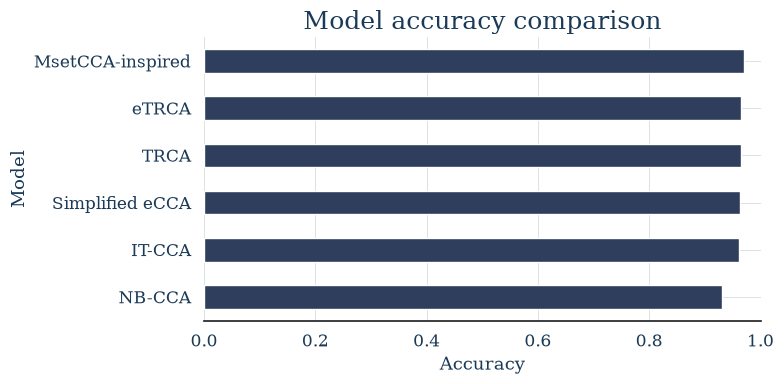

In [ ]:
plot_accuracy_bar(advanced_summary_df)


In [ ]:
advanced_per_class_comparison = pd.DataFrame({
    "NB_CCA": per_class_accuracy(nbcca_df_advanced),
    "IT_CCA": per_class_accuracy(itcca_df_advanced),
    "eCCA_simplified": per_class_accuracy(ecca_df_advanced),
    "MsetCCA_inspired": per_class_accuracy(msetcca_df_advanced),
    "TRCA": per_class_accuracy(trca_df_advanced),
    "eTRCA": per_class_accuracy(etrca_df_advanced),
})

advanced_per_class_comparison


,NB_CCA,IT_CCA,eCCA_simplified,MsetCCA_inspired,TRCA,eTRCA
true_label,,,,,,
5.45,0.984,0.964,0.972,0.992,0.984,0.980
6.67,0.916,0.952,0.960,0.964,0.984,0.980
8.57,0.920,0.976,0.984,0.984,0.980,0.984
12.00,0.904,0.952,0.940,0.940,0.912,0.916


## 13.10 Advanced-method interpretation

These methods answer a different question than calibration-free CCA/FBCCA. CCA and FBCCA ask: *how far can we get using predefined sine/cosine references?* Template-based methods ask: *how much can we improve if training/calibration trials are available?*

When interpreting results, compare:

- calibration-free methods: CCA, FBCCA, NB-CCA,
- template/calibration methods: IT-CCA, simplified eCCA, MsetCCA-inspired, TRCA, eTRCA.

If TRCA/eTRCA or template-based methods clearly outperform CCA/FBCCA, it supports the conclusion that a practical SSVEP control system should include user-specific calibration.


## 13.9b Subject-mixed vs. subject-dependent comparison

The table and plot below compare pooled-subject calibration with subject-dependent calibration for the trainable methods. The purpose is methodological: it shows how the validation protocol changes the result when templates or spatial filters are learned from data.

Calibration-free methods are included only as reference lines because they do not depend on the train/test calibration split in the same way.


In [ ]:
fix_comparison_results = [
    {"model": "IT-CCA (subject-mixed)", "df": itcca_df_advanced,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "subject-mixed CV"},
    {"model": "IT-CCA (subject-dependent)", "df": itcca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "subject-dependent CV"},
    {"model": "Simplified eCCA (subject-mixed)", "df": ecca_df_advanced,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "subject-mixed CV"},
    {"model": "Simplified eCCA (subject-dependent)", "df": ecca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "subject-dependent CV"},
    {"model": "MsetCCA-inspired (subject-mixed)", "df": msetcca_df_advanced,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "subject-mixed CV"},
    {"model": "MsetCCA-inspired (subject-dependent)", "df": msetcca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "subject-dependent CV"},
    {"model": "TRCA (subject-mixed)", "df": trca_df_advanced,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "subject-mixed CV"},
    {"model": "TRCA (subject-dependent)", "df": trca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "subject-dependent CV"},
    {"model": "eTRCA (subject-mixed)", "df": etrca_df_advanced,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "subject-mixed CV"},
    {"model": "eTRCA (subject-dependent)", "df": etrca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "subject-dependent CV"},
    {"model": "FB-eTRCA (subject-dependent)", "df": fbtrca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "subject-dependent CV"},
    {"model": "NB-CCA (reference, calibration-free)", "df": nbcca_df_advanced,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "calibration-free reference"},
]

fix_comparison_df = summarize_model_results(fix_comparison_results)
fix_comparison_df


,model,n_classes,chance_level,accuracy,balanced_accuracy,gain_over_chance,comment
10,FB-eTRCA (subject-dependent),4,0.25,0.992,0.992,0.742,subject-dependent CV
9,eTRCA (subject-dependent),4,0.25,0.988,0.988,0.738,subject-dependent CV
7,TRCA (subject-dependent),4,0.25,0.987,0.987,0.737,subject-dependent CV
5,MsetCCA-inspired (subject-dependent),4,0.25,0.971,0.971,0.721,subject-dependent CV
4,MsetCCA-inspired (subject-mixed),4,0.25,0.970,0.970,0.720,subject-mixed CV
1,IT-CCA (subject-dependent),4,0.25,0.966,0.966,0.716,subject-dependent CV
8,eTRCA (subject-mixed),4,0.25,0.965,0.965,0.715,subject-mixed CV
6,TRCA (subject-mixed),4,0.25,0.965,0.965,0.715,subject-mixed CV
2,Simplified eCCA (subject-mixed),4,0.25,0.964,0.964,0.714,subject-mixed CV
0,IT-CCA (subject-mixed),4,0.25,0.961,0.961,0.711,subject-mixed CV


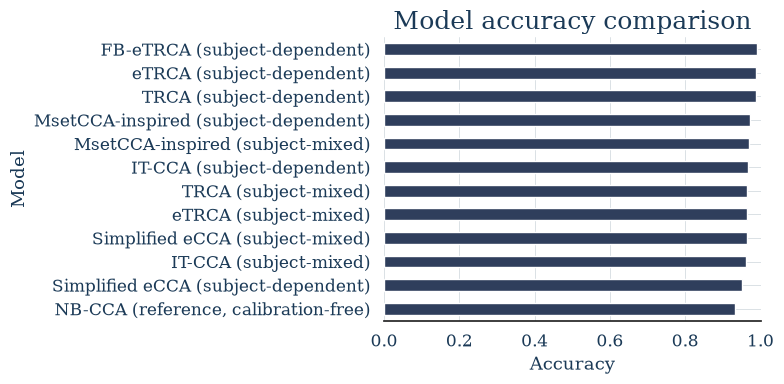

In [ ]:
plot_accuracy_bar(fix_comparison_df)


### 13.9b Interpretation

The subject-mixed and subject-dependent rows should be interpreted as different evaluation protocols, not as a guaranteed ranking. For calibration-dependent SSVEP methods, the subject-dependent protocol is the more relevant one when the intended system will be calibrated separately for each user.

If the calibrated methods remain weaker than expected, the main diagnostic directions are:

- trial-window length and onset trimming,
- subject-wise variability,
- posterior versus broader channel sets,
- filter-bank design,
- the exact target-scoring implementation used by TRCA/eTRCA.

Section 21 evaluates these issues more systematically and should be used for the final robustness conclusions.


# 14. Frequency selection analysis

## 14.1 Motivation

Class-wise accuracy may reveal that some stimulation frequencies are much easier to classify than others. In a practical SSVEP control system, weak frequencies should not automatically be assigned to important commands.

## 14.2 4-class setup

The 4-class setup uses all available Lee2019_SSVEP target frequencies:

```text
5.45, 6.67, 8.57, 12.00 Hz
```

This is the primary problem because it preserves all four directional commands.

## 14.3 3-class setup without 5.45 Hz


In [ ]:
TARGET_FREQS_3 = [6.67, 8.57, 12.00]

X_3, labels_3, metadata_3, X_posterior_3 = make_frequency_subset(
    X=X,
    labels_float=labels_float,
    metadata=metadata,
    selected_target_freqs=TARGET_FREQS_3,
    channel_indices=POSTERIOR_CHANNEL_INDICES,
)

fbcca_df_3 = fbcca_predict(
    trials=X_posterior_3,
    true_labels=labels_3,
    target_freqs=TARGET_FREQS_3,
    fs=FS,
    filter_bands=DEFAULT_FBCCA_BANDS,
    n_harmonics=3,
    metadata=metadata_3,
)

print_metrics(fbcca_df_3, "FBCCA 3-class without 5.45 Hz")
print("Per-class accuracy:")
print(per_class_accuracy(fbcca_df_3))


FBCCA 3-class without 5.45 Hz accuracy: 98.13%
FBCCA 3-class without 5.45 Hz balanced accuracy: 98.13%

              precision    recall  f1-score   support

       12.00      0.984     0.972     0.978       250
        6.67      0.988     0.984     0.986       250
        8.57      0.972     0.988     0.980       250

    accuracy                          0.981       750
   macro avg      0.981     0.981     0.981       750
weighted avg      0.981     0.981     0.981       750

Per-class accuracy:
true_label
6.67     0.984
8.57     0.988
12.00    0.972
Name: correct, dtype: float64


## 14.4 2-class setup


In [ ]:
TARGET_FREQS_2 = [8.57, 12.00]

X_2, labels_2, metadata_2, X_posterior_2 = make_frequency_subset(
    X=X,
    labels_float=labels_float,
    metadata=metadata,
    selected_target_freqs=TARGET_FREQS_2,
    channel_indices=POSTERIOR_CHANNEL_INDICES,
)

fbcca_df_2 = fbcca_predict(
    trials=X_posterior_2,
    true_labels=labels_2,
    target_freqs=TARGET_FREQS_2,
    fs=FS,
    filter_bands=DEFAULT_FBCCA_BANDS,
    n_harmonics=3,
    metadata=metadata_2,
)

print_metrics(fbcca_df_2, "FBCCA 2-class")
print("Per-class accuracy:")
print(per_class_accuracy(fbcca_df_2))


FBCCA 2-class accuracy: 98.60%
FBCCA 2-class balanced accuracy: 98.60%

              precision    recall  f1-score   support

       12.00      0.992     0.980     0.986       250
        8.57      0.980     0.992     0.986       250

    accuracy                          0.986       500
   macro avg      0.986     0.986     0.986       500
weighted avg      0.986     0.986     0.986       500

Per-class accuracy:
true_label
8.57     0.992
12.00    0.980
Name: correct, dtype: float64


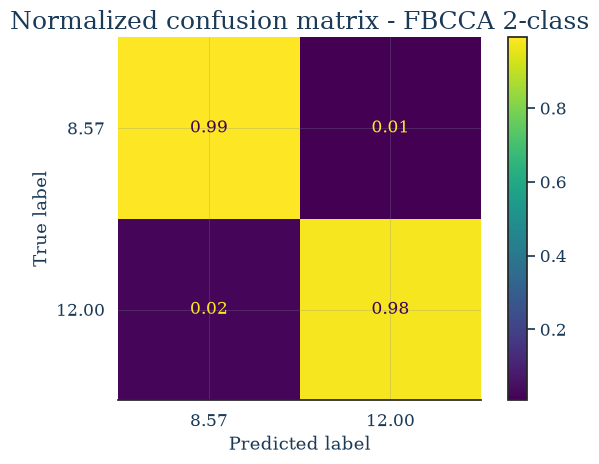

In [ ]:
plot_confusion(
    fbcca_df_2,
    labels_order=TARGET_FREQS_2,
    title="Normalized confusion matrix - FBCCA 2-class",
)


## 14.5 Comparison table

In [ ]:
frequency_selection_summary = summarize_model_results([
    {
        "model": "FBCCA 4-class",
        "df": fbcca_df_4,
        "n_classes": 4,
        "comment": "all available frequencies",
    },
    {
        "model": "FBCCA 3-class",
        "df": fbcca_df_3,
        "n_classes": 3,
        "comment": "without 5.45 Hz",
    },
    {
        "model": "FBCCA 2-class",
        "df": fbcca_df_2,
        "n_classes": 2,
        "comment": "8.57, 12.00 Hz",
    },
])

frequency_selection_summary


,model,n_classes,chance_level,accuracy,balanced_accuracy,gain_over_chance,comment
2,FBCCA 2-class,2,0.500000,0.986000,0.986000,0.486,"8.57, 12.00 Hz"
1,FBCCA 3-class,3,0.333333,0.981333,0.981333,0.648,without 5.45 Hz
0,FBCCA 4-class,4,0.250000,0.976000,0.976000,0.726,all available frequencies


## 14.6 Interpretation

The reduced-class results are exploratory design experiments. A higher raw accuracy after removing one or more frequencies does not mean that the classifier itself improved, because the classification problem becomes easier and the chance level increases.


# 15. Model comparison

## 15.1 Summary table

In [ ]:
base_model_results = [
    {
        "model": "SNR baseline 4-class",
        "df": snr_df_4,
        "n_classes": 4,
        "comment": "simple spectral baseline",
    },
    {
        "model": "CCA 4-class",
        "df": cca_df_4,
        "n_classes": 4,
        "comment": "standard CCA",
    },
    {
        "model": "FBCCA 4-class",
        "df": fbcca_df_4,
        "n_classes": 4,
        "comment": "filter-bank CCA",
    },
    {
        "model": "FBCCA 3-class",
        "df": fbcca_df_3,
        "n_classes": 3,
        "comment": "without 5.45 Hz",
    },
    {
        "model": "FBCCA 2-class",
        "df": fbcca_df_2,
        "n_classes": 2,
        "comment": "selected frequencies",
    },
]

# Add advanced-method results if Section 13 has been executed.
if "advanced_model_results" in globals():
    model_summary_df = summarize_model_results(base_model_results + advanced_model_results)
else:
    model_summary_df = summarize_model_results(base_model_results)

model_summary_df


,model,n_classes,chance_level,accuracy,balanced_accuracy,gain_over_chance,comment
4,FBCCA 2-class,2,0.500000,0.986000,0.986000,0.486,selected frequencies
3,FBCCA 3-class,3,0.333333,0.981333,0.981333,0.648,without 5.45 Hz
2,FBCCA 4-class,4,0.250000,0.976000,0.976000,0.726,filter-bank CCA
8,MsetCCA-inspired,4,0.250000,0.970000,0.970000,0.720,"learned class references, CV"
9,TRCA,4,0.250000,0.965000,0.965000,0.715,"class-specific spatial filters, CV"
10,eTRCA,4,0.250000,0.965000,0.965000,0.715,"ensemble TRCA filters, CV"
7,Simplified eCCA,4,0.250000,0.964000,0.964000,0.714,"reference + template score, CV"
6,IT-CCA,4,0.250000,0.961000,0.961000,0.711,"individual templates, CV"
1,CCA 4-class,4,0.250000,0.951000,0.951000,0.701,standard CCA
5,NB-CCA,4,0.250000,0.931000,0.931000,0.681,"narrow-band, no templates"


### 15.1b Including the subject-dependent fixed methods

The cell below extends the section 15.1 comparison with the subject-dependent
(fixed) calibrated methods and FB-eTRCA from section 13, if they were run.


In [ ]:
fixed_method_results = [
    {"model": "IT-CCA (subject-dependent)", "df": itcca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "individual templates, subject CV"},
    {"model": "Simplified eCCA (subject-dependent)", "df": ecca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "reference + template, subject CV"},
    {"model": "MsetCCA-inspired (subject-dependent)", "df": msetcca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "learned references, subject CV"},
    {"model": "TRCA (subject-dependent)", "df": trca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "spatial filters, subject CV"},
    {"model": "eTRCA (subject-dependent)", "df": etrca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "ensemble filters, subject CV"},
    {"model": "FB-eTRCA (subject-dependent)", "df": fbtrca_df_advanced_subjectcv,
     "n_classes": len(ADVANCED_TARGET_FREQS), "comment": "filter-bank + TRCA, subject CV"},
]

if "advanced_model_results" in globals():
    all_names = {r["model"] for r in base_model_results + advanced_model_results}
else:
    all_names = {r["model"] for r in base_model_results}

model_summary_df_full = summarize_model_results(
    base_model_results
    + (advanced_model_results if "advanced_model_results" in globals() else [])
    + fixed_method_results
)
model_summary_df_full


,model,n_classes,chance_level,accuracy,balanced_accuracy,gain_over_chance,comment
16,FB-eTRCA (subject-dependent),4,0.250000,0.992000,0.992000,0.742,"filter-bank + TRCA, subject CV"
15,eTRCA (subject-dependent),4,0.250000,0.988000,0.988000,0.738,"ensemble filters, subject CV"
14,TRCA (subject-dependent),4,0.250000,0.987000,0.987000,0.737,"spatial filters, subject CV"
4,FBCCA 2-class,2,0.500000,0.986000,0.986000,0.486,selected frequencies
3,FBCCA 3-class,3,0.333333,0.981333,0.981333,0.648,without 5.45 Hz
2,FBCCA 4-class,4,0.250000,0.976000,0.976000,0.726,filter-bank CCA
13,MsetCCA-inspired (subject-dependent),4,0.250000,0.971000,0.971000,0.721,"learned references, subject CV"
8,MsetCCA-inspired,4,0.250000,0.970000,0.970000,0.720,"learned class references, CV"
11,IT-CCA (subject-dependent),4,0.250000,0.966000,0.966000,0.716,"individual templates, subject CV"
10,eTRCA,4,0.250000,0.965000,0.965000,0.715,"ensemble TRCA filters, CV"


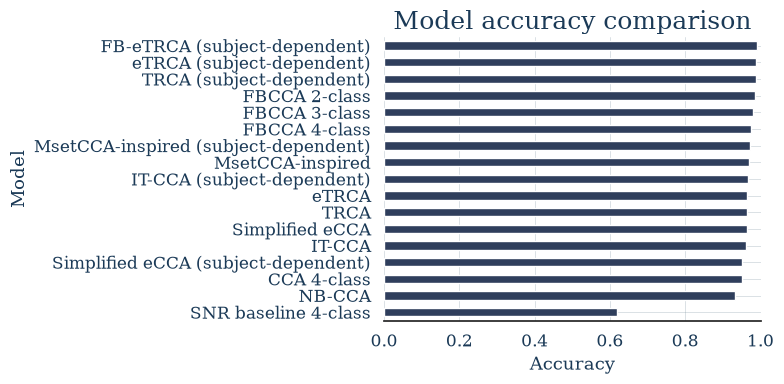

In [ ]:
plot_accuracy_bar(model_summary_df_full)


## 15.2 Accuracy bar plot

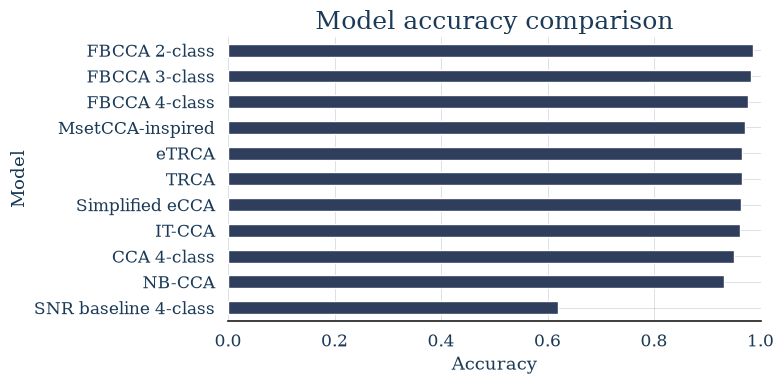

In [ ]:
plot_accuracy_bar(model_summary_df)

## 15.3 Per-class comparison

In [ ]:
per_class_comparison = pd.DataFrame({
    "SNR_4_class": per_class_accuracy(snr_df_4),
    "CCA_4_class": per_class_accuracy(cca_df_4),
    "FBCCA_4_class": per_class_accuracy(fbcca_df_4),
})

per_class_comparison


,SNR_4_class,CCA_4_class,FBCCA_4_class
true_label,,,
5.45,0.628,0.980,0.992
6.67,0.508,0.944,0.976
8.57,0.628,0.976,0.980
12.00,0.712,0.904,0.956


## 15.4 Practical interpretation

The practical interpretation should focus on whether the classification accuracy is high enough for stable control. Frequencies with consistently weak per-class accuracy should be treated cautiously or excluded from the command set.

# 16. Subject-wise analysis

## 16.1 Why subject-wise analysis matters

EEG and SSVEP responses vary strongly between subjects. A global accuracy value can hide high performance for some participants and poor performance for others. Therefore, subject-wise accuracy is important for evaluating whether user-specific calibration may be required.

## 16.2 Add subject metadata

The prediction functions above attach subject/session/run metadata whenever those columns are available in the MOABB metadata table.

## 16.3 Accuracy per subject

subject
1     0.90
2     1.00
3     0.99
4     1.00
5     1.00
6     1.00
7     1.00
8     0.88
9     0.99
10    1.00
Name: correct, dtype: float64


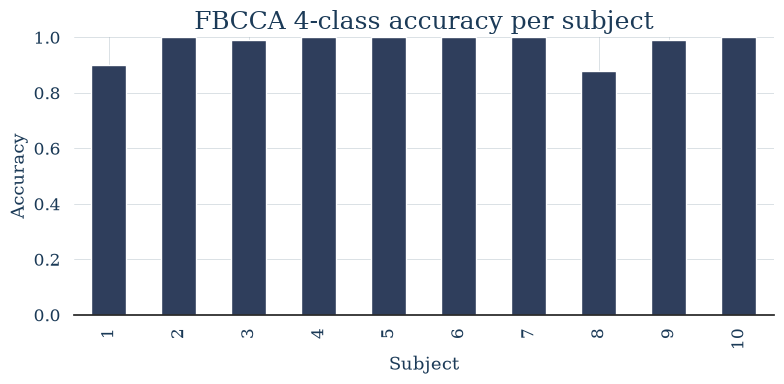

In [ ]:
if "subject" in fbcca_df_4.columns:
    subject_accuracy_fbcca = (
        fbcca_df_4
        .groupby("subject")["correct"]
        .mean()
        .sort_index()
    )
    print(subject_accuracy_fbcca)

    ax = subject_accuracy_fbcca.plot(kind="bar", figsize=(8, 4))
    ax.set_xlabel("Subject")
    ax.set_ylabel("Accuracy")
    ax.set_title("FBCCA 4-class accuracy per subject")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()
else:
    print("Subject metadata not available in prediction results.")


## 16.4 Interpretation

Large differences between subjects would suggest that a real system should include subject-specific calibration and possibly subject-specific frequency selection.

# 17. Error analysis

## 17.1 Confusion matrix analysis

The confusion matrix should be used to identify which target frequencies are confused with each other.

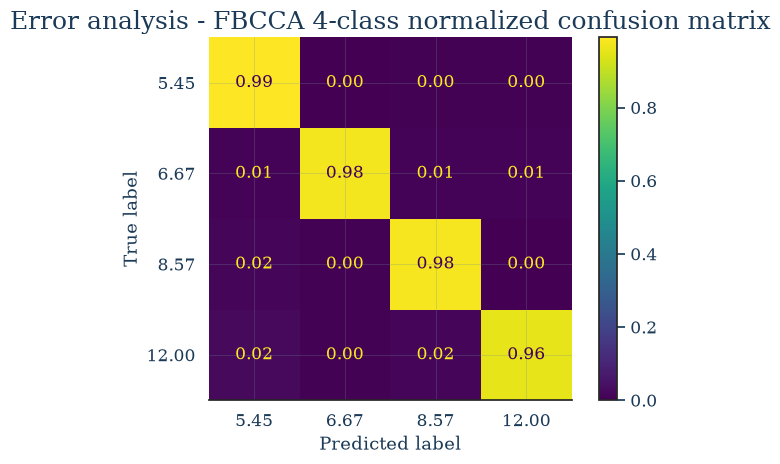

In [ ]:
plot_confusion(
    fbcca_df_4,
    labels_order=TARGET_FREQS_ALL,
    title="Error analysis - FBCCA 4-class normalized confusion matrix",
)


## 17.2 Weak frequencies

The weakest frequencies should be identified from per-class accuracy, local SNR and confusion matrices after the Lee2019_SSVEP run. No frequency should be labeled as weak in advance solely because of its numerical value.

## 17.3 Possible causes

Possible reasons for weaker classes include:

- weaker SSVEP response for some stimulation frequencies,
- overlap with background EEG activity,
- weaker or noisier harmonic structure,
- individual subject variability,
- channel selection,
- trial-onset latency or unstable early response.

## 17.4 Consequences for control system

Weak frequencies should not be assigned to critical real-time control commands unless they are validated with additional data and subject-specific calibration.


# 18. Practical BCI control system discussion

## 18.1 Directional command mapping

Lee2019_SSVEP already provides a natural four-direction mapping:

```text
12.00 Hz -> up
8.57 Hz  -> left
6.67 Hz  -> right
5.45 Hz  -> down
```

This makes the full 4-class problem directly relevant to a four-direction drone/object control prototype.

## 18.2 Recommended number of commands

The full 4-class setup should remain the primary evaluation. Reduced 3-class or 2-class variants can be used only as exploratory reliability/latency studies if one frequency proves consistently weak.

## 18.3 Safety layer

A real control system should include safety mechanisms:

- no-command threshold,
- low-confidence rejection,
- majority voting across consecutive windows,
- confirmation command for critical actions,
- emergency stop or manual override.

## 18.4 Real-time considerations

Real-time SSVEP classification requires a trade-off between speed and accuracy. Longer windows usually improve frequency resolution and classification stability, but increase command latency.


# 19. Future work

The advanced methods above are implemented as transparent notebook-level versions. Further work should focus on:

## 19.1 Parameter tuning

- systematic grid search for CCA/FBCCA bands,
- harmonic selection,
- narrow-band width tuning,
- trial trimming and window length selection,
- channel subset selection.

## 19.2 Validation protocol

- subject-wise train/test splits,
- leave-one-subject-out testing,
- within-subject calibration vs cross-subject generalization,
- repeated cross-validation with confidence intervals.

## 19.3 Reference implementations

Compare the custom educational implementations with library implementations from MOABB and SSVEP Analysis Toolbox, especially for TRCA, eTRCA and MsetCCA.

## 19.4 Real hardware validation

The final system should be validated with the intended LED/monitor stimulation setup, online predictions, no-command rejection and safety confirmation logic.


# 20. Interim conclusions before the v5 robustness run

## 20.1 What Sections 1–19 establish

After executing the Lee2019_SSVEP notebook, Sections 1–19 provide:

1. spectral evidence from PSD and local-SNR analysis,
2. calibration-free baselines from SNR, CCA and FBCCA,
3. calibrated/template-based comparisons from IT-CCA, eCCA, MsetCCA, TRCA and eTRCA,
4. exploratory reduced-class comparisons,
5. subject-wise and error analyses.

The full 4-class result should remain the primary control-system result because it preserves the dataset's four directional commands.

## 20.2 Important methodological rule

Any reduced frequency subset selected after looking at the current dataset is an exploratory design result, not an unbiased final benchmark. Likewise, channel, onset-trim and filter-bank settings selected from the same data must be reported as exploratory optimization.

## 20.3 v5 conclusion policy

Section 21 performs the robustness and corrected-evaluation analysis. Final conclusions should report:

- pooled accuracy and balanced accuracy,
- mean / median / standard deviation across subjects,
- 95% bootstrap confidence interval across subjects,
- class count and chance level,
- whether a configuration was pre-specified or selected exploratorily.


## 20.4 Subject-dependent calibration note

The subject-dependent evaluation functions are retained because template/spatial-filter methods such as IT-CCA, TRCA and eTRCA are designed to learn subject-specific structure. Mixing different subjects inside a calibration fold can obscure that structure and can also make the evaluation protocol difficult to interpret.

Section 21 therefore keeps strict within-subject folds for the corrected TRCA-family analysis and reports subject-level performance explicitly.


# 21. Accuracy optimization and robustness analysis (v5)

This section is the **current analysis layer**. Sections 1–20 provide the general EDA/baseline workflow, while Section 21 adds stricter robustness analysis.

The goals here are:

- improve scientific correctness before optimizing accuracy,
- make subject variability explicit,
- separate deterministic preprocessing from trainable methods,
- validate TRCA/eTRCA scoring against the equations used in the original TRCA framework,
- perform only small, hypothesis-driven channel / onset / FBCCA studies,
- avoid presenting exploratory frequency selection or hyperparameter selection as an unbiased final benchmark.

Unless stated otherwise, the primary design study uses the full Lee2019_SSVEP 4-class problem `5.45 / 6.67 / 8.57 / 12.00 Hz` because it directly represents the four directional commands.


## 21.1 Preprocessing audit and v5 experiment configuration

### Documented source and notebook preprocessing

Lee2019_SSVEP contains 62 EEG channels recorded at 1000 Hz with a nasion reference. The dataset implementation exposes 4-second SSVEP trials at 5.45, 6.67, 8.57 and 12.00 Hz.

In this notebook, the MOABB `SSVEP` paradigm is configured explicitly with:

- `fmin=4.0 Hz`,
- `fmax=45.0 Hz`,
- `resample=250 Hz`.

The lower cutoff is intentionally below 5.45 Hz so that the fundamental component of the lowest-frequency class is not removed.

References:

- MOABB Lee2019_SSVEP documentation: https://moabb.neurotechx.com/docs/generated/moabb.datasets.Lee2019_SSVEP.html
- Lee et al. 2019 dataset paper: https://doi.org/10.1093/gigascience/giz002

### Consequence for v5

A further broad 5–45 Hz filter is **not treated as automatically necessary** for the v5 calibration-free base methods because the MOABB paradigm already applies the explicit 4–45 Hz analysis band. Filter-bank methods still apply their sub-band filters because this decomposition is part of the classifier itself.

If an additional broad filter is tested, it should be reported as an explicit preprocessing variant rather than silently stacked on top of the paradigm-level filtering.


In [ ]:
# v5 experiment configuration — deliberately small and explicit.
V5_TARGET_FREQS_2 = [8.57, 12.00]
V5_TARGET_FREQS_3 = [6.67, 8.57, 12.00]
V5_TARGET_FREQS_4 = [5.45, 6.67, 8.57, 12.00]

V5_CHANNEL_SETS = {
    "O1_O2": [LEE2019_CHANNELS.index("O1"), LEE2019_CHANNELS.index("O2")],
    "posterior_8": [LEE2019_CHANNELS.index(ch) for ch in POSTERIOR_CHANNELS],
    "all_62": list(range(len(LEE2019_CHANNELS))),
}

# Current notebook filter bank and a low-frequency-adapted alternative.
V5_FBANDS_CURRENT = [(5, 45), (10, 45), (15, 45)]
V5_FBANDS_LOW_FREQ = [(4, 45), (9, 45), (14, 45)]

V5_TRIM_OPTIONS_SEC = [0.0, 0.25, 0.50]
V5_N_SPLITS = 5
V5_BOOTSTRAP_ITERATIONS = 5000
V5_QC_ROBUST_Z_THRESHOLD = 5.0

# Expensive studies can be disabled independently while debugging the notebook.
V5_RUN_CHANNEL_STUDY = False
V5_RUN_TRIM_STUDY = False
V5_RUN_FBCCA_GRID = False

# Explicit label mapping for reporting. The existing notebook still stores physical
# frequencies as labels for backwards compatibility.
V5_CLASS_TO_FREQ = {idx: freq for idx, freq in enumerate(V5_TARGET_FREQS_4)}
V5_FREQ_TO_CLASS = {freq: idx for idx, freq in V5_CLASS_TO_FREQ.items()}

print("v5 4-class frequencies:", V5_TARGET_FREQS_4)
print("v5 channel sets:", {k: [LEE2019_CHANNELS[i] for i in v] for k, v in V5_CHANNEL_SETS.items()})


# These three studies are intentionally opt-in in the split advanced notebook.
# Set an individual flag to True when you specifically want to run that study.


In [ ]:
def v5_validate_trials(
    trials: np.ndarray,
    labels: np.ndarray,
    metadata: pd.DataFrame | None = None,
) -> None:
    """Basic shape/finite-value assertions used before v5 experiments."""
    trials = np.asarray(trials)
    labels = np.asarray(labels)

    if trials.ndim != 3:
        raise ValueError(f"Expected trials shape (n_trials, n_channels, n_samples), got {trials.shape}.")
    if trials.shape[0] != len(labels):
        raise ValueError("Number of trials and labels does not match.")
    if metadata is not None and len(metadata) != len(labels):
        raise ValueError("Metadata length does not match labels.")
    if not np.all(np.isfinite(trials)):
        raise ValueError("Non-finite values found in EEG tensor.")


def v5_prepare_trials(
    trials: np.ndarray,
    fs: int,
    channel_indices: list[int] | None = None,
    trim_start_sec: float = 0.0,
    broad_filter_band: tuple[float, float] | None = None,
    filter_order: int = 4,
) -> np.ndarray:
    """Deterministic v5 preprocessing: channel selection -> trim -> optional broad filter.

    The default broad_filter_band=None is intentional because the MOABB SSVEP paradigm
    already applies the explicit 4–45 Hz analysis band configured in Section 5.
    Filter-bank classifiers apply their own sub-band decomposition separately.
    """
    X = np.asarray(trials, dtype=float)

    if channel_indices is not None:
        X = X[:, channel_indices, :]

    X = trim_trials(X, fs=fs, trim_start_sec=trim_start_sec)

    if broad_filter_band is not None:
        lowcut, highcut = broad_filter_band
        X = filter_eeg_trials(
            X,
            lowcut=lowcut,
            highcut=highcut,
            fs=fs,
            order=filter_order,
            filter_type="butter",
        )

    return X


def v5_make_subset(
    trials: np.ndarray,
    labels: np.ndarray,
    metadata: pd.DataFrame,
    target_freqs: list[float],
) -> tuple[np.ndarray, np.ndarray, pd.DataFrame]:
    """Selects a frequency subset without changing channel structure."""
    labels_float_local = np.asarray(labels, dtype=float)
    mask = np.isin(labels_float_local, np.asarray(target_freqs, dtype=float))
    X_sub = np.asarray(trials)[mask]
    y_sub = labels_float_local[mask]
    meta_sub = metadata.loc[mask].reset_index(drop=True)
    v5_validate_trials(X_sub, y_sub, meta_sub)
    return X_sub, y_sub, meta_sub


# Core v5 subsets from the array returned by MOABB.
X_v5_2_all, y_v5_2, meta_v5_2 = v5_make_subset(X, labels_float, metadata, V5_TARGET_FREQS_2)
X_v5_3_all, y_v5_3, meta_v5_3 = v5_make_subset(X, labels_float, metadata, V5_TARGET_FREQS_3)
X_v5_4_all, y_v5_4, meta_v5_4 = v5_make_subset(X, labels_float, metadata, V5_TARGET_FREQS_4)

X_v5_2_post = v5_prepare_trials(X_v5_2_all, FS, V5_CHANNEL_SETS["posterior_8"])
X_v5_3_post = v5_prepare_trials(X_v5_3_all, FS, V5_CHANNEL_SETS["posterior_8"])
X_v5_4_post = v5_prepare_trials(X_v5_4_all, FS, V5_CHANNEL_SETS["posterior_8"])

print("X_v5_4_post:", X_v5_4_post.shape)


X_v5_4_post: (1000, 8, 1000)


In [ ]:
# Compact audit table: source-level processing vs notebook-level operations.
preprocessing_audit_v5 = pd.DataFrame([
    {
        "stage": "Lee2019_SSVEP source",
        "operation": "1000 Hz EEG, nasion reference",
        "v5_action": "Keep source reference; resample through the MOABB paradigm",
    },
    {
        "stage": "MOABB SSVEP paradigm",
        "operation": "4–45 Hz band-pass + resample to 250 Hz",
        "v5_action": "Base CCA/TRCA start without another broad band-pass",
    },
    {
        "stage": "Lee2019_SSVEP source",
        "operation": "60 Hz line-frequency environment",
        "v5_action": "45 Hz analysis upper bound excludes the 60 Hz line component",
    },
    {
        "stage": "v5 filter-bank methods",
        "operation": "sub-band filtering",
        "v5_action": "Keep: this is part of FBCCA / FB-TRCA",
    },
    {
        "stage": "v5 optional experiment",
        "operation": "additional broad band-pass",
        "v5_action": "Only as an explicitly labeled variant",
    },
])
preprocessing_audit_v5


,stage,operation,v5_action
0,Lee2019_SSVEP source,"1000 Hz EEG, nasion reference",Keep source reference; resample through the MO...
1,MOABB SSVEP paradigm,4–45 Hz band-pass + resample to 250 Hz,Base CCA/TRCA start without another broad band...
2,Lee2019_SSVEP source,60 Hz line-frequency environment,45 Hz analysis upper bound excludes the 60 Hz ...
3,v5 filter-bank methods,sub-band filtering,Keep: this is part of FBCCA / FB-TRCA
4,v5 optional experiment,additional broad band-pass,Only as an explicitly labeled variant


## 21.2 Reference-Aligned TRCA and eTRCA (v5.1 Corrected Implementation)

The Section 13 TRCA implementation learned a plausible spatial filter but used `rho ** 2` directly as the **single-band base TRCA** class score. In the original TRCA formulation, the single-band class score is the Pearson correlation between the spatially filtered test trial and averaged class template, and the target is selected by the maximum correlation.

For ensemble TRCA, class-specific filters are stacked into an ensemble matrix `W`, and the test/template matrices are jointly projected. The original method uses a **2-D correlation** between those projected matrices. Here this is implemented by vectorizing the two equally shaped projected matrices before Pearson correlation, which is equivalent to correlating their concatenated entries.

For filter-bank fusion, the original TRCA framework uses:

\[
\rho_n = \sum_m a(m)\left(r_n^{(m)}\right)^2,
\qquad a(m)=m^{-1.25}+0.25.
\]

Therefore, squaring is retained at the **filter-bank fusion stage**, not at the base single-band TRCA decision stage.

Primary reference: Nakanishi et al., *Enhancing Detection of SSVEPs for a High-Speed Brain Speller Using Task-Related Component Analysis*.


In [ ]:
def v5_learn_trca_filter(
    class_trials: np.ndarray,
    reg: float = 1e-6,
) -> np.ndarray:
    """Reference-like TRCA spatial filter for one stimulus class.

    S: summed inter-trial cross-covariance.
    Q: covariance-like matrix of concatenated centered training trials.
    The dominant generalized eigenvector maximizes w.T @ S @ w / (w.T @ Q @ w).
    """
    trials = np.asarray(class_trials, dtype=float)
    if trials.ndim != 3 or trials.shape[0] < 2:
        raise ValueError("TRCA requires at least two training trials for a class.")

    # Remove per-channel temporal mean in every trial before covariance construction.
    trials_c = trials - trials.mean(axis=2, keepdims=True)
    n_trials, n_channels, _ = trials_c.shape

    S = np.zeros((n_channels, n_channels), dtype=float)
    for i in range(n_trials - 1):
        Xi = trials_c[i]
        for j in range(i + 1, n_trials):
            Xj = trials_c[j]
            # Add both directions explicitly to keep S symmetric.
            S += Xi @ Xj.T + Xj @ Xi.T

    concatenated = np.concatenate([trials_c[i] for i in range(n_trials)], axis=1)
    Q = concatenated @ concatenated.T

    # Scale-aware ridge regularization for numerical stability only.
    scale = np.trace(Q) / max(n_channels, 1)
    if not np.isfinite(scale) or scale <= 0:
        scale = 1.0
    Q_reg = Q + reg * scale * np.eye(n_channels)

    S = 0.5 * (S + S.T)
    Q_reg = 0.5 * (Q_reg + Q_reg.T)

    eigvals, eigvecs = eigh(S, Q_reg)
    w = np.real(eigvecs[:, int(np.argmax(np.real(eigvals)))])
    norm = np.linalg.norm(w)
    if norm == 0:
        raise ValueError("Degenerate TRCA spatial filter.")
    return w / norm


def v5_train_trca_model(
    X_train: np.ndarray,
    y_train: np.ndarray,
    target_freqs: list[float],
) -> tuple[dict[float, np.ndarray], dict[float, np.ndarray]]:
    """Learns averaged class templates and one TRCA filter per class."""
    templates = build_class_templates(X_train, y_train, target_freqs)
    y_train = np.asarray(y_train, dtype=float)
    filters = {}

    for freq in target_freqs:
        f = float(freq)
        class_trials = X_train[np.isclose(y_train, f, atol=0.01)]
        filters[f] = v5_learn_trca_filter(class_trials)

    return templates, filters


def v5_trca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Single-band TRCA using signed Pearson correlation for target scoring."""
    del fs  # data are already prepared before entering this classifier
    templates, filters = v5_train_trca_model(X_train, y_train, target_freqs)
    rows = []

    for trial_idx, trial in enumerate(X_test):
        scores = {}
        for freq in target_freqs:
            f = float(freq)
            w = filters[f]
            rho = safe_corrcoef(w @ trial, w @ templates[f])
            scores[f] = rho

        pred = max(scores, key=scores.get)
        row = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(pred),
            "trca_score": float(scores[pred]),
        }
        for f, score in scores.items():
            row[f"TRCA_{f:.2f}"] = float(score)
        rows.append(add_metadata_to_result(row, metadata_test, trial_idx))

    df = pd.DataFrame(rows)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


def v5_etrca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """Reference-like ensemble TRCA using 2-D correlation after ensemble projection."""
    del fs
    templates, filters = v5_train_trca_model(X_train, y_train, target_freqs)
    W = np.column_stack([filters[float(f)] for f in target_freqs])  # channels x classes
    rows = []

    for trial_idx, trial in enumerate(X_test):
        projected_test = trial.T @ W  # time x ensemble-components
        scores = {}

        for freq in target_freqs:
            f = float(freq)
            projected_template = templates[f].T @ W
            # 2-D correlation: concatenate all corresponding projected entries.
            rho_2d = safe_corrcoef(projected_test.ravel(), projected_template.ravel())
            scores[f] = rho_2d

        pred = max(scores, key=scores.get)
        row = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(pred),
            "etrca_score": float(scores[pred]),
        }
        for f, score in scores.items():
            row[f"eTRCA_{f:.2f}"] = float(score)
        rows.append(add_metadata_to_result(row, metadata_test, trial_idx))

    df = pd.DataFrame(rows)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


In [ ]:
def v5_fbtrca_train_test_predict(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata_test: pd.DataFrame | None = None,
    filter_bands: list[tuple[float, float]] | None = None,
    filter_order: int = 4,
    ensemble: bool = True,
    weights: np.ndarray | None = None,
) -> pd.DataFrame:
    """Filter-bank TRCA/eTRCA with standard weighted squared-correlation fusion.

    Each sub-band trains its own TRCA model. The base sub-band score is a signed
    correlation (TRCA or 2-D eTRCA). Only the final filter-bank fusion squares it.
    """
    if filter_bands is None:
        filter_bands = V5_FBANDS_CURRENT

    if weights is None:
        weights = np.array([
            (m + 1) ** (-1.25) + 0.25
            for m in range(len(filter_bands))
        ], dtype=float)
    else:
        weights = np.asarray(weights, dtype=float)

    if len(weights) != len(filter_bands):
        raise ValueError("weights length must match filter_bands length.")

    band_models = []
    for lowcut, highcut in filter_bands:
        Xtr_b = filter_eeg_trials(
            X_train, lowcut=lowcut, highcut=highcut, fs=fs,
            order=filter_order, filter_type="butter",
        )
        Xte_b = filter_eeg_trials(
            X_test, lowcut=lowcut, highcut=highcut, fs=fs,
            order=filter_order, filter_type="butter",
        )
        templates, filters = v5_train_trca_model(Xtr_b, y_train, target_freqs)
        W = np.column_stack([filters[float(f)] for f in target_freqs])
        band_models.append((Xte_b, templates, filters, W))

    rows = []
    for trial_idx in range(len(X_test)):
        fused_scores = {float(f): 0.0 for f in target_freqs}

        for band_idx, (Xte_b, templates, filters, W) in enumerate(band_models):
            trial_b = Xte_b[trial_idx]

            for freq in target_freqs:
                f = float(freq)
                if ensemble:
                    rho = safe_corrcoef(
                        (trial_b.T @ W).ravel(),
                        (templates[f].T @ W).ravel(),
                    )
                else:
                    w = filters[f]
                    rho = safe_corrcoef(w @ trial_b, w @ templates[f])

                fused_scores[f] += float(weights[band_idx] * (rho ** 2))

        pred = max(fused_scores, key=fused_scores.get)
        row = {
            "trial": trial_idx,
            "true_label": float(y_test[trial_idx]),
            "predicted_label": float(pred),
            "fbtrca_score": float(fused_scores[pred]),
            "ensemble": bool(ensemble),
        }
        rows.append(add_metadata_to_result(row, metadata_test, trial_idx))

    df = pd.DataFrame(rows)
    df["correct"] = np.isclose(df["true_label"], df["predicted_label"], atol=0.01)
    return df


In [ ]:
def v5_subject_dependent_cv(
    method_fn,
    trials: np.ndarray,
    labels: np.ndarray,
    target_freqs: list[float],
    fs: int,
    metadata: pd.DataFrame,
    n_splits: int = V5_N_SPLITS,
    random_state: int = RANDOM_STATE,
    **method_kwargs,
) -> pd.DataFrame:
    """Strict within-subject CV with explicit leakage assertions and test indices."""
    v5_validate_trials(trials, labels, metadata)
    if "subject" not in metadata.columns:
        raise ValueError("metadata must contain a subject column.")

    labels = np.asarray(labels, dtype=float)
    meta = metadata.reset_index(drop=True)
    subjects = meta["subject"].to_numpy()
    all_rows = []

    for subject_id in np.unique(subjects):
        subject_global_idx = np.flatnonzero(subjects == subject_id)
        Xs = trials[subject_global_idx]
        ys = labels[subject_global_idx]
        ms = meta.iloc[subject_global_idx].reset_index(drop=True)

        cv_labels = make_cv_labels(ys)
        min_class_count = int(pd.Series(cv_labels).value_counts().min())
        effective_splits = min(int(n_splits), min_class_count)
        if effective_splits < 2:
            print(f"Skipping subject {subject_id}: not enough trials per class.")
            continue

        skf = StratifiedKFold(
            n_splits=effective_splits,
            shuffle=True,
            random_state=random_state,
        )

        for fold_idx, (train_idx, test_idx) in enumerate(
            skf.split(np.zeros(len(ys)), cv_labels),
            start=1,
        ):
            # Leakage / protocol assertions.
            assert np.intersect1d(train_idx, test_idx).size == 0
            assert set(ms.iloc[train_idx]["subject"].unique()) == {subject_id}
            assert set(ms.iloc[test_idx]["subject"].unique()) == {subject_id}

            meta_test = ms.iloc[test_idx].reset_index(drop=True)
            fold_df = method_fn(
                X_train=Xs[train_idx],
                y_train=ys[train_idx],
                X_test=Xs[test_idx],
                y_test=ys[test_idx],
                target_freqs=target_freqs,
                fs=fs,
                metadata_test=meta_test,
                **method_kwargs,
            )

            fold_df["subject"] = subject_id
            fold_df["fold"] = fold_idx
            fold_df["trial_subset_index"] = subject_global_idx[test_idx]
            all_rows.append(fold_df)

    if not all_rows:
        raise ValueError("No valid subject-dependent folds were produced.")

    return pd.concat(all_rows, ignore_index=True)


In [ ]:
# Corrected 4-class subject-dependent TRCA-family benchmark on posterior-8 channels.
# No extra broad band-pass is applied here; the filter-bank method applies its own sub-bands.
trca_df_v5 = v5_subject_dependent_cv(
    v5_trca_train_test_predict,
    X_v5_4_post,
    y_v5_4,
    V5_TARGET_FREQS_4,
    FS,
    meta_v5_4,
)

etrca_df_v5 = v5_subject_dependent_cv(
    v5_etrca_train_test_predict,
    X_v5_4_post,
    y_v5_4,
    V5_TARGET_FREQS_4,
    FS,
    meta_v5_4,
)

fbtrca_df_v5 = v5_subject_dependent_cv(
    v5_fbtrca_train_test_predict,
    X_v5_4_post,
    y_v5_4,
    V5_TARGET_FREQS_4,
    FS,
    meta_v5_4,
    filter_bands=V5_FBANDS_CURRENT,
    ensemble=False,
)

fbetrca_df_v5 = v5_subject_dependent_cv(
    v5_fbtrca_train_test_predict,
    X_v5_4_post,
    y_v5_4,
    V5_TARGET_FREQS_4,
    FS,
    meta_v5_4,
    filter_bands=V5_FBANDS_CURRENT,
    ensemble=True,
)

for name, df in {
    "TRCA v5": trca_df_v5,
    "eTRCA v5": etrca_df_v5,
    "FB-TRCA v5": fbtrca_df_v5,
    "FB-eTRCA v5": fbetrca_df_v5,
}.items():
    print_metrics(df, name)
    print()


TRCA v5 accuracy: 99.30%
TRCA v5 balanced accuracy: 99.30%

              precision    recall  f1-score   support

       12.00      0.992     0.984     0.988       250
        5.45      0.984     1.000     0.992       250
        6.67      0.996     0.992     0.994       250
        8.57      1.000     0.996     0.998       250

    accuracy                          0.993      1000
   macro avg      0.993     0.993     0.993      1000
weighted avg      0.993     0.993     0.993      1000


eTRCA v5 accuracy: 99.00%
eTRCA v5 balanced accuracy: 99.00%

              precision    recall  f1-score   support

       12.00      0.988     0.980     0.984       250
        5.45      0.984     1.000     0.992       250
        6.67      0.988     0.988     0.988       250
        8.57      1.000     0.992     0.996       250

    accuracy                          0.990      1000
   macro avg      0.990     0.990     0.990      1000
weighted avg      0.990     0.990     0.990      1000


FB-TRC

## 21.3 Subject-level performance: subject × method

Pooled trial accuracy is kept because it answers a valid trial-level question, but it is no longer the only summary. For a BCI with strong responder/non-responder variability, every method is also summarized across subjects using:

- mean subject accuracy,
- median subject accuracy,
- standard deviation across subjects,
- bootstrap 95% CI for the mean across subjects.

The bootstrap resamples **subjects**, not individual trials, because subjects are the independent units of interest for this summary.


In [ ]:
def v5_bootstrap_mean_ci(
    values,
    n_boot: int = V5_BOOTSTRAP_ITERATIONS,
    ci: float = 0.95,
    random_state: int = RANDOM_STATE,
) -> tuple[float, float]:
    values = np.asarray(pd.Series(values).dropna(), dtype=float)
    if len(values) == 0:
        return np.nan, np.nan
    if len(values) == 1:
        return float(values[0]), float(values[0])

    rng = np.random.default_rng(random_state)
    samples = rng.choice(values, size=(n_boot, len(values)), replace=True)
    means = samples.mean(axis=1)
    alpha = (1 - ci) / 2
    return (
        float(np.quantile(means, alpha)),
        float(np.quantile(means, 1 - alpha)),
    )


def v5_subject_accuracy_series(df: pd.DataFrame) -> pd.Series:
    if "subject" not in df.columns:
        raise ValueError("Prediction dataframe does not contain subject metadata.")
    return df.groupby("subject")["correct"].mean().sort_index()


def v5_subject_method_table(method_dfs: dict[str, pd.DataFrame]) -> tuple[pd.DataFrame, pd.DataFrame]:
    per_subject = pd.concat(
        {name: v5_subject_accuracy_series(df) for name, df in method_dfs.items()},
        axis=1,
    ).sort_index()

    summary_rows = []
    for method in per_subject.columns:
        values = per_subject[method].dropna()
        lo, hi = v5_bootstrap_mean_ci(values)
        summary_rows.append({
            "method": method,
            "mean_subject_accuracy": values.mean(),
            "median_subject_accuracy": values.median(),
            "std_subject_accuracy": values.std(ddof=1),
            "ci95_low": lo,
            "ci95_high": hi,
            "n_subjects": len(values),
        })

    return per_subject, pd.DataFrame(summary_rows).set_index("method")


# Recompute calibration-free 4-class methods in the v5 preprocessing convention.
cca_df_4_v5 = cca_predict(
    trials=X_v5_4_post,
    true_labels=y_v5_4,
    target_freqs=V5_TARGET_FREQS_4,
    fs=FS,
    filter_band=None,
    n_harmonics=3,
    metadata=meta_v5_4,
)

fbcca_df_4_v5 = fbcca_predict(
    trials=X_v5_4_post,
    true_labels=y_v5_4,
    target_freqs=V5_TARGET_FREQS_4,
    fs=FS,
    filter_bands=V5_FBANDS_CURRENT,
    n_harmonics=3,
    metadata=meta_v5_4,
)

v5_subject_methods = {
    "CCA": cca_df_4_v5,
    "FBCCA": fbcca_df_4_v5,
    "NB-CCA": nbcca_df_advanced,
    "TRCA-v5": trca_df_v5,
    "eTRCA-v5": etrca_df_v5,
    "FB-TRCA-v5": fbtrca_df_v5,
    "FB-eTRCA-v5": fbetrca_df_v5,
}

subject_method_table_v5, subject_method_summary_v5 = v5_subject_method_table(v5_subject_methods)
subject_method_table_v5


,CCA,FBCCA,NB-CCA,TRCA-v5,eTRCA-v5,FB-TRCA-v5,FB-eTRCA-v5
subject,,,,,,,
1,0.90,0.90,0.87,0.96,0.95,0.93,0.94
2,1.00,1.00,0.94,1.00,1.00,1.00,1.00
3,0.98,0.99,0.93,1.00,0.99,1.00,1.00
4,1.00,1.00,1.00,1.00,1.00,1.00,1.00
5,0.98,1.00,0.92,1.00,1.00,0.99,0.99
6,1.00,1.00,1.00,1.00,1.00,1.00,1.00
7,1.00,1.00,1.00,0.99,0.99,1.00,1.00
8,0.67,0.88,0.74,0.98,0.98,0.99,1.00
9,0.98,0.99,0.95,1.00,0.99,1.00,1.00


In [ ]:
subject_method_summary_v5


,mean_subject_accuracy,median_subject_accuracy,std_subject_accuracy,ci95_low,ci95_high,n_subjects
method,,,,,,
CCA,0.951,0.990,0.103328,0.879000,0.994,10
FBCCA,0.976,1.000,0.045753,0.944000,0.999,10
NB-CCA,0.931,0.945,0.078804,0.876975,0.971,10
TRCA-v5,0.993,1.000,0.013375,0.984000,1.000,10
eTRCA-v5,0.990,0.995,0.015635,0.979000,0.998,10
FB-TRCA-v5,0.991,1.000,0.021833,0.976000,1.000,10
FB-eTRCA-v5,0.993,1.000,0.018886,0.980000,1.000,10


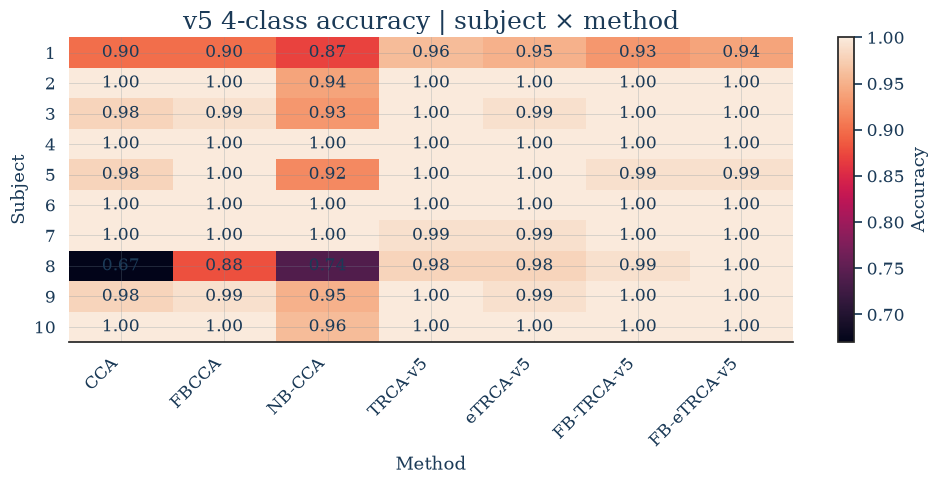

In [ ]:
# Heatmap: subject x method accuracy.
fig, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(subject_method_table_v5.to_numpy(), aspect="auto")
ax.set_xticks(np.arange(subject_method_table_v5.shape[1]))
ax.set_xticklabels(subject_method_table_v5.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(subject_method_table_v5.shape[0]))
ax.set_yticklabels(subject_method_table_v5.index)
ax.set_xlabel("Method")
ax.set_ylabel("Subject")
ax.set_title("v5 4-class accuracy | subject × method")
fig.colorbar(image, ax=ax, label="Accuracy")

for i in range(subject_method_table_v5.shape[0]):
    for j in range(subject_method_table_v5.shape[1]):
        value = subject_method_table_v5.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center")

plt.tight_layout()
plt.show()


## 21.4 SNR heatmap: subject × stimulation frequency

For each trial, the SNR value used here is the local SNR evaluated at the **true stimulation frequency**. The heatmap reports the median trial-level SNR in dB for each subject × frequency cell.

This separates two hypotheses:

- a generally weak/noisy participant,
- a participant who responds poorly only to a particular stimulation frequency.

The heatmap is recomputed from the predefined posterior channels without an additional broad notebook-level filter, so the preprocessing choice remains explicit.


In [ ]:
snr_df_4_v5 = build_snr_dataframe(
    trials=X_v5_4_post,
    true_labels=y_v5_4,
    target_freqs=V5_TARGET_FREQS_4,
    fs=FS,
    metadata=meta_v5_4,
)


def v5_true_target_snr_db(row: pd.Series) -> float:
    return float(row[f"SNRdB_{float(row['true_label']):.2f}"])

snr_df_4_v5["true_target_snr_db"] = snr_df_4_v5.apply(v5_true_target_snr_db, axis=1)

snr_subject_frequency_v5 = snr_df_4_v5.pivot_table(
    index="subject",
    columns="true_label",
    values="true_target_snr_db",
    aggfunc="median",
).sort_index()

snr_subject_frequency_v5


true_label,5.45,6.67,8.57,12.00
subject,,,,
1,0.453853,3.156134,2.737177,1.312680
2,2.577546,-0.681926,7.117508,9.993730
3,8.659240,5.202495,4.117695,11.580644
4,10.798147,7.256766,14.425579,13.514349
5,2.679794,5.765546,10.099618,10.245149
6,7.797159,7.037752,4.681947,5.700483
7,4.456406,4.570275,5.217874,3.747890
8,0.187709,0.515301,2.896488,1.463124
9,-0.278066,0.336148,2.196287,4.547179


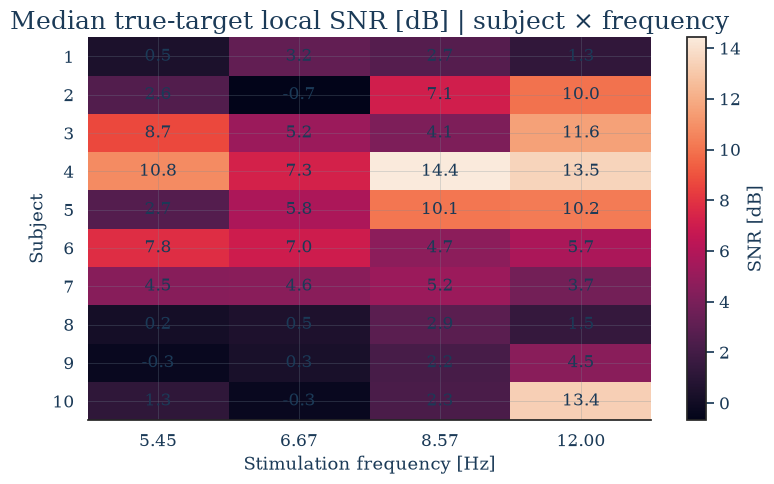

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
image = ax.imshow(snr_subject_frequency_v5.to_numpy(), aspect="auto")
ax.set_xticks(np.arange(snr_subject_frequency_v5.shape[1]))
ax.set_xticklabels([f"{float(f):.2f}" for f in snr_subject_frequency_v5.columns])
ax.set_yticks(np.arange(snr_subject_frequency_v5.shape[0]))
ax.set_yticklabels(snr_subject_frequency_v5.index)
ax.set_xlabel("Stimulation frequency [Hz]")
ax.set_ylabel("Subject")
ax.set_title("Median true-target local SNR [dB] | subject × frequency")
fig.colorbar(image, ax=ax, label="SNR [dB]")

for i in range(snr_subject_frequency_v5.shape[0]):
    for j in range(snr_subject_frequency_v5.shape[1]):
        value = snr_subject_frequency_v5.iloc[i, j]
        if pd.notna(value):
            ax.text(j, i, f"{value:.1f}", ha="center", va="center")

plt.tight_layout()
plt.show()


## 21.5 Fundamental and harmonic analysis

For the full 4-class design, the first three frequency components are:

- 5.45, 10.90, 16.35 Hz,
- 6.67, 13.34, 20.01 Hz,
- 8.57, 17.14, 25.71 Hz,
- 12.00, 24.00, 36.00 Hz.

All are below the 45 Hz upper bound used in the notebook-level analyses. This section computes local SNR for each component and additionally compares SNR at a target component on trials of the corresponding class versus all non-target trials.

### PSD estimator note

The existing notebook often calls `welch(..., nperseg=trial_length)`. With a 4 s trial this produces effectively a single long segment, so it behaves closer to a windowed periodogram than to the classical multi-segment Welch estimator. That choice is retained here for **frequency resolution** and is described explicitly rather than attributing variance reduction to segment averaging.


In [ ]:
def v5_harmonic_snr_scan(
    trials: np.ndarray,
    labels: np.ndarray,
    metadata: pd.DataFrame,
    target_freqs: list[float],
    fs: int,
    harmonics: tuple[int, ...] = (1, 2, 3),
    max_freq: float = 45.0,
) -> pd.DataFrame:
    """Computes SNR at every target-frequency harmonic on every trial once PSD is available."""
    rows = []
    labels = np.asarray(labels, dtype=float)
    metadata = metadata.reset_index(drop=True)

    for trial_idx, trial in enumerate(trials):
        freqs, psd = compute_trial_mean_psd(
            trial=trial,
            fs=fs,
            nperseg=trial.shape[1],  # full-window / periodogram-like for resolution
        )

        for target_freq in target_freqs:
            for h in harmonics:
                component_freq = float(target_freq) * h
                if component_freq > min(max_freq, fs / 2):
                    continue

                _, snr_db = compute_snr_at_freq(
                    freqs=freqs,
                    psd=psd,
                    target_freq=component_freq,
                    noise_width=2,
                    skip_width=1,
                )

                rows.append({
                    "trial": trial_idx,
                    "subject": metadata.iloc[trial_idx]["subject"],
                    "true_label": float(labels[trial_idx]),
                    "target_freq": float(target_freq),
                    "harmonic": int(h),
                    "component_freq": component_freq,
                    "is_target_trial": bool(np.isclose(labels[trial_idx], target_freq, atol=0.01)),
                    "snr_db": snr_db,
                })

    return pd.DataFrame(rows)


harmonic_snr_v5 = v5_harmonic_snr_scan(
    X_v5_4_post,
    y_v5_4,
    meta_v5_4,
    V5_TARGET_FREQS_4,
    FS,
)

harmonic_target_summary_v5 = (
    harmonic_snr_v5[harmonic_snr_v5["is_target_trial"]]
    .groupby(["target_freq", "harmonic", "component_freq"])["snr_db"]
    .median()
    .rename("median_target_snr_db")
    .reset_index()
)

harmonic_target_summary_v5


,target_freq,harmonic,component_freq,median_target_snr_db
0,5.45,1,5.45,3.452926
1,5.45,2,10.90,5.198916
2,5.45,3,16.35,6.288779
3,6.67,1,6.67,3.788409
4,6.67,2,13.34,6.906846
5,6.67,3,20.01,6.500411
6,8.57,1,8.57,5.355552
7,8.57,2,17.14,6.937879
8,8.57,3,25.71,3.970009
9,12.00,1,12.00,7.403592


In [ ]:
target_snr = (
    harmonic_snr_v5[harmonic_snr_v5["is_target_trial"]]
    .groupby(["target_freq", "harmonic", "component_freq"])["snr_db"]
    .median()
    .rename("target_median_snr_db")
)

nontarget_snr = (
    harmonic_snr_v5[~harmonic_snr_v5["is_target_trial"]]
    .groupby(["target_freq", "harmonic", "component_freq"])["snr_db"]
    .median()
    .rename("nontarget_median_snr_db")
)

harmonic_contrast_v5 = pd.concat([target_snr, nontarget_snr], axis=1).reset_index()
harmonic_contrast_v5["target_minus_nontarget_db"] = (
    harmonic_contrast_v5["target_median_snr_db"]
    - harmonic_contrast_v5["nontarget_median_snr_db"]
)

harmonic_contrast_v5


,target_freq,harmonic,component_freq,target_median_snr_db,nontarget_median_snr_db,target_minus_nontarget_db
0,5.45,1,5.45,3.452926,-0.812165,4.265091
1,5.45,2,10.90,5.198916,-1.339637,6.538553
2,5.45,3,16.35,6.288779,-1.868797,8.157576
3,6.67,1,6.67,3.788409,-0.840269,4.628678
4,6.67,2,13.34,6.906846,-0.553783,7.460629
5,6.67,3,20.01,6.500411,-0.818403,7.318814
6,8.57,1,8.57,5.355552,-0.209749,5.565301
7,8.57,2,17.14,6.937879,-1.968607,8.906486
8,8.57,3,25.71,3.970009,-0.912763,4.882772
9,12.00,1,12.00,7.403592,-0.996548,8.400140


## 21.6 Predefined channel-set analysis

⚠️ **EXPLORATORY DESIGN STUDY**: This section is NOT a hyperparameter optimization via grid search. It tests a small predefined physiological hypothesis using three fixed montages. Results here must not be presented as an independent final benchmark — the same dataset is used to inform the comparison.

Only three pre-specified montages are compared:

1. `O1 + O2`,
2. the 8-channel posterior set `PO9 + PO3 + POz + PO4 + PO10 + O1 + Oz + O2`,
3. all 62 available EEG channels.

This is intentionally **not** an exhaustive channel search. The purpose is to test a small physiological hypothesis: CCA/FBCCA may already work well on posterior channels, whereas TRCA/eTRCA spatial filters may benefit from a broader montage.

Because the three sets are defined before looking at the v5 results, the study is less prone to channel-selection overfitting than brute-force subset search. It is still exploratory because the same dataset is used to compare configurations.


In [ ]:
def v5_result_metrics_row(
    df: pd.DataFrame,
    method: str,
    n_classes: int,
    **extra,
) -> dict:
    subject_acc = v5_subject_accuracy_series(df) if "subject" in df.columns else pd.Series(dtype=float)
    lo, hi = v5_bootstrap_mean_ci(subject_acc) if len(subject_acc) else (np.nan, np.nan)
    row = {
        "method": method,
        "n_classes": n_classes,
        "chance_level": 1 / n_classes,
        "pooled_accuracy": safe_accuracy(df),
        "balanced_accuracy": safe_balanced_accuracy(df),
        "mean_subject_accuracy": subject_acc.mean() if len(subject_acc) else np.nan,
        "median_subject_accuracy": subject_acc.median() if len(subject_acc) else np.nan,
        "std_subject_accuracy": subject_acc.std(ddof=1) if len(subject_acc) > 1 else np.nan,
        "ci95_low": lo,
        "ci95_high": hi,
    }
    row["gain_over_chance"] = row["pooled_accuracy"] - row["chance_level"]
    row.update(extra)
    return row


channel_study_rows_v5 = []
channel_study_dfs_v5 = {}

if V5_RUN_CHANNEL_STUDY:
    for channel_set_name, channel_indices in V5_CHANNEL_SETS.items():
        Xc = v5_prepare_trials(X_v5_4_all, FS, channel_indices=channel_indices)

        cca_df = cca_predict(
            Xc, y_v5_4, V5_TARGET_FREQS_4, FS,
            filter_band=None, n_harmonics=3, metadata=meta_v5_4,
        )
        fbcca_df = fbcca_predict(
            Xc, y_v5_4, V5_TARGET_FREQS_4, FS,
            filter_bands=V5_FBANDS_CURRENT, n_harmonics=3, metadata=meta_v5_4,
        )
        trca_df = v5_subject_dependent_cv(
            v5_trca_train_test_predict, Xc, y_v5_4,
            V5_TARGET_FREQS_4, FS, meta_v5_4,
        )
        etrca_df = v5_subject_dependent_cv(
            v5_etrca_train_test_predict, Xc, y_v5_4,
            V5_TARGET_FREQS_4, FS, meta_v5_4,
        )

        for method_name, df in {
            "CCA": cca_df,
            "FBCCA": fbcca_df,
            "TRCA-v5": trca_df,
            "eTRCA-v5": etrca_df,
        }.items():
            channel_study_dfs_v5[(channel_set_name, method_name)] = df
            channel_study_rows_v5.append(v5_result_metrics_row(
                df,
                method=method_name,
                n_classes=4,
                channel_set=channel_set_name,
                n_channels=len(channel_indices),
            ))

channel_study_v5 = pd.DataFrame(channel_study_rows_v5)
channel_study_v5.sort_values(["method", "pooled_accuracy"], ascending=[True, False]) if len(channel_study_v5) else channel_study_v5


## 21.7 Trial-onset trimming study

⚠️ **EXPLORATORY DESIGN STUDY**: This section compares fixed onset-trimming values on the same dataset. Any trim value selected after inspecting these results must be reported as exploratory optimization, not as an independent finding.

The hypothesis is that the earliest part of a stimulus epoch may contain transient visual activity or a less stable steady-state response. The v5 grid is deliberately small: `0.00`, `0.25`, and `0.50 s`.

This remains an **exploratory hyperparameter study**. The best trim value must not be presented as if it were chosen on independent test data. Removing more time also shortens the available 4-second steady-state window, so the default grid remains conservative.


In [ ]:
trim_study_rows_v5 = []
trim_study_dfs_v5 = {}

if V5_RUN_TRIM_STUDY:
    Xbase = v5_prepare_trials(
        X_v5_4_all,
        FS,
        channel_indices=V5_CHANNEL_SETS["posterior_8"],
    )

    for trim_sec in V5_TRIM_OPTIONS_SEC:
        Xt = trim_trials(Xbase, FS, trim_start_sec=trim_sec)

        cca_df = cca_predict(
            Xt, y_v5_4, V5_TARGET_FREQS_4, FS,
            filter_band=None, n_harmonics=3, metadata=meta_v5_4,
        )
        fbcca_df = fbcca_predict(
            Xt, y_v5_4, V5_TARGET_FREQS_4, FS,
            filter_bands=V5_FBANDS_CURRENT, n_harmonics=3, metadata=meta_v5_4,
        )
        trca_df = v5_subject_dependent_cv(
            v5_trca_train_test_predict, Xt, y_v5_4,
            V5_TARGET_FREQS_4, FS, meta_v5_4,
        )
        etrca_df = v5_subject_dependent_cv(
            v5_etrca_train_test_predict, Xt, y_v5_4,
            V5_TARGET_FREQS_4, FS, meta_v5_4,
        )

        for method_name, df in {
            "CCA": cca_df,
            "FBCCA": fbcca_df,
            "TRCA-v5": trca_df,
            "eTRCA-v5": etrca_df,
        }.items():
            trim_study_dfs_v5[(trim_sec, method_name)] = df
            trim_study_rows_v5.append(v5_result_metrics_row(
                df,
                method=method_name,
                n_classes=4,
                trim_start_sec=trim_sec,
                remaining_duration_sec=Xt.shape[2] / FS,
            ))

trim_study_v5 = pd.DataFrame(trim_study_rows_v5)
trim_study_v5.sort_values(["method", "pooled_accuracy"], ascending=[True, False]) if len(trim_study_v5) else trim_study_v5


## 21.8 Small FBCCA hyperparameter study

⚠️ **EXPLORATORY DESIGN STUDY**: This section compares FBCCA variants on the same dataset. Any configuration selected after inspecting these results must be reported as exploratory optimization.

The existing FBCCA implementation already uses the standard structure:

\\[
\\text{score}_f = \\sum_m w_m \\rho_{f,m}^2,
\\qquad w_m=m^{-a}+b.
\\]

Therefore, `rho²` is **kept** for FBCCA. The v5 study does not brute-force arbitrary parameters. It compares a few interpretable alternatives around the current `a=1.25, b=0.25` choice and one literature-inspired lower-cutoff progression adapted to the source sampling/bandwidth.

Because the same dataset is used to compare these configurations, this table is an optimization/design study, not an unbiased final test.


In [ ]:
def v5_fb_weights(n_bands: int, a: float = 1.25, b: float = 0.25) -> np.ndarray:
    return np.array([(m + 1) ** (-a) + b for m in range(n_bands)], dtype=float)


V5_FBCCA_CONFIGS = [
    {"name": "current_h2", "bands": V5_FBANDS_CURRENT, "n_harmonics": 2, "a": 1.25, "b": 0.25},
    {"name": "current_h3", "bands": V5_FBANDS_CURRENT, "n_harmonics": 3, "a": 1.25, "b": 0.25},
    {"name": "a1.00_b0.25", "bands": V5_FBANDS_CURRENT, "n_harmonics": 3, "a": 1.00, "b": 0.25},
    {"name": "a1.50_b0.25", "bands": V5_FBANDS_CURRENT, "n_harmonics": 3, "a": 1.50, "b": 0.25},
    {"name": "a1.25_b0.00", "bands": V5_FBANDS_CURRENT, "n_harmonics": 3, "a": 1.25, "b": 0.00},
    {"name": "low_freq_adapted_h3", "bands": V5_FBANDS_LOW_FREQ, "n_harmonics": 3, "a": 1.25, "b": 0.25},
]

fbcca_grid_rows_v5 = []
fbcca_grid_dfs_v5 = {}

if V5_RUN_FBCCA_GRID:
    for cfg in V5_FBCCA_CONFIGS:
        weights = v5_fb_weights(len(cfg["bands"]), cfg["a"], cfg["b"])
        df = fbcca_predict(
            trials=X_v5_4_post,
            true_labels=y_v5_4,
            target_freqs=V5_TARGET_FREQS_4,
            fs=FS,
            filter_bands=cfg["bands"],
            n_harmonics=cfg["n_harmonics"],
            metadata=meta_v5_4,
            weights=weights,
        )
        fbcca_grid_dfs_v5[cfg["name"]] = df
        fbcca_grid_rows_v5.append(v5_result_metrics_row(
            df,
            method="FBCCA",
            n_classes=4,
            config=cfg["name"],
            n_harmonics=cfg["n_harmonics"],
            a=cfg["a"],
            b=cfg["b"],
            filter_bands=str(cfg["bands"]),
        ))

fbcca_grid_v5 = pd.DataFrame(fbcca_grid_rows_v5)
fbcca_grid_v5.sort_values("pooled_accuracy", ascending=False) if len(fbcca_grid_v5) else fbcca_grid_v5


## 21.9 Non-destructive trial-quality analysis

This section does **not** remove trials. It computes simple QC features independent of classifier correctness:

- maximum channel peak-to-peak amplitude,
- median channel variance,
- median channel MAD,
- median absolute kurtosis.

Robust z-scores are calculated across trials and a conservative flag is shown only as a diagnostic. No threshold is tuned to maximize classification accuracy, and the number/fraction of flagged trials is reported explicitly.


In [ ]:
from scipy.stats import kurtosis


def v5_mad(x: np.ndarray, axis=None) -> np.ndarray:
    med = np.median(x, axis=axis, keepdims=True)
    return np.median(np.abs(x - med), axis=axis)


def v5_trial_qc_table(
    trials: np.ndarray,
    labels: np.ndarray,
    metadata: pd.DataFrame,
) -> pd.DataFrame:
    rows = []
    for i, trial in enumerate(np.asarray(trials, dtype=float)):
        channel_ptp = np.ptp(trial, axis=1)
        channel_var = np.var(trial, axis=1)
        channel_mad = v5_mad(trial, axis=1)
        channel_kurt = kurtosis(trial, axis=1, fisher=True, bias=False, nan_policy="omit")

        rows.append({
            "trial": i,
            "subject": metadata.iloc[i]["subject"],
            "true_label": float(labels[i]),
            "peak_to_peak_max": float(np.nanmax(channel_ptp)),
            "variance_median": float(np.nanmedian(channel_var)),
            "mad_median": float(np.nanmedian(channel_mad)),
            "abs_kurtosis_median": float(np.nanmedian(np.abs(channel_kurt))),
        })

    qc = pd.DataFrame(rows)
    metric_cols = [
        "peak_to_peak_max", "variance_median", "mad_median", "abs_kurtosis_median"
    ]

    for col in metric_cols:
        med = qc[col].median()
        mad = np.median(np.abs(qc[col] - med))
        scale = 1.4826 * mad
        if scale <= 0 or not np.isfinite(scale):
            qc[f"rz_{col}"] = 0.0
        else:
            qc[f"rz_{col}"] = (qc[col] - med) / scale

    rz_cols = [f"rz_{col}" for col in metric_cols]
    qc["qc_flag"] = qc[rz_cols].abs().max(axis=1) > V5_QC_ROBUST_Z_THRESHOLD
    return qc


qc_trials_v5 = v5_trial_qc_table(X_v5_4_post, y_v5_4, meta_v5_4)
print(f"QC flagged trials: {qc_trials_v5['qc_flag'].sum()} / {len(qc_trials_v5)} "
      f"({qc_trials_v5['qc_flag'].mean():.2%})")

qc_subject_summary_v5 = qc_trials_v5.groupby("subject").agg(
    peak_to_peak_median=("peak_to_peak_max", "median"),
    variance_median=("variance_median", "median"),
    mad_median=("mad_median", "median"),
    abs_kurtosis_median=("abs_kurtosis_median", "median"),
    qc_flag_fraction=("qc_flag", "mean"),
)
qc_subject_summary_v5


QC flagged trials: 78 / 1000 (7.80%)


,peak_to_peak_median,variance_median,mad_median,abs_kurtosis_median,qc_flag_fraction
subject,,,,,
1,60.696482,68.884570,5.501805,0.275813,0.04
2,49.919908,40.795500,3.963033,0.978789,0.15
3,74.618197,94.119776,6.351317,0.245718,0.05
4,35.042305,19.941221,3.021437,0.188969,0.01
5,68.701086,58.149114,4.885819,0.476911,0.12
6,64.417579,58.335412,4.974187,0.288573,0.12
7,71.974696,68.105849,5.058434,1.095175,0.19
8,89.088580,129.356091,7.364923,0.372462,0.03
9,40.686424,32.143238,3.811942,0.212994,0.02


## 21.10 Fair comparison by class count

A 2-class, 3-class and 4-class classifier solve different tasks and have different chance levels. v5 therefore produces **three separate benchmark tables**.

Frequency-set reduction remains a separate design study. A higher raw accuracy after removing classes is not interpreted as a pure model improvement.

For every table, `gain_over_chance = pooled_accuracy - chance_level` is included only as a descriptive aid; it does not replace accuracy, balanced accuracy or subject-level statistics.


In [ ]:
# Recompute the calibration-free baselines under one explicit v5 convention:
# posterior-8, no extra broad filter for SNR/CCA, filter bank only where required.

def v5_calibration_free_set(
    X_post: np.ndarray,
    y: np.ndarray,
    meta: pd.DataFrame,
    target_freqs: list[float],
) -> dict[str, pd.DataFrame]:
    snr_df = build_snr_dataframe(
        X_post, y, target_freqs, FS, metadata=meta,
    )
    cca_df = cca_predict(
        X_post, y, target_freqs, FS,
        filter_band=None, n_harmonics=3, metadata=meta,
    )
    fbcca_df = fbcca_predict(
        X_post, y, target_freqs, FS,
        filter_bands=V5_FBANDS_CURRENT, n_harmonics=3, metadata=meta,
    )
    return {"SNR": snr_df, "CCA": cca_df, "FBCCA": fbcca_df}


v5_methods_4 = v5_calibration_free_set(X_v5_4_post, y_v5_4, meta_v5_4, V5_TARGET_FREQS_4)
v5_methods_3 = v5_calibration_free_set(X_v5_3_post, y_v5_3, meta_v5_3, V5_TARGET_FREQS_3)
v5_methods_2 = v5_calibration_free_set(X_v5_2_post, y_v5_2, meta_v5_2, V5_TARGET_FREQS_2)

# Add the corrected calibrated methods only to the matching full 4-class problem.
v5_methods_4.update({
    "NB-CCA": nbcca_df_advanced,
    "TRCA-v5": trca_df_v5,
    "eTRCA-v5": etrca_df_v5,
    "FB-TRCA-v5": fbtrca_df_v5,
    "FB-eTRCA-v5": fbetrca_df_v5,
})


def v5_benchmark_table(method_dfs: dict[str, pd.DataFrame], n_classes: int) -> pd.DataFrame:
    rows = [
        v5_result_metrics_row(df, method=name, n_classes=n_classes)
        for name, df in method_dfs.items()
    ]
    return pd.DataFrame(rows).sort_values("pooled_accuracy", ascending=False).reset_index(drop=True)


benchmark_4class_v5 = v5_benchmark_table(v5_methods_4, 4)
benchmark_3class_v5 = v5_benchmark_table(v5_methods_3, 3)
benchmark_2class_v5 = v5_benchmark_table(v5_methods_2, 2)

print("4-class benchmark")
display(benchmark_4class_v5)
print("3-class benchmark")
display(benchmark_3class_v5)
print("2-class benchmark")
display(benchmark_2class_v5)


4-class benchmark


,method,n_classes,chance_level,pooled_accuracy,balanced_accuracy,mean_subject_accuracy,median_subject_accuracy,std_subject_accuracy,ci95_low,ci95_high,gain_over_chance
0,FB-eTRCA-v5,4,0.25,0.993,0.993,0.993,1.000,0.018886,0.980000,1.000,0.743
1,TRCA-v5,4,0.25,0.993,0.993,0.993,1.000,0.013375,0.984000,1.000,0.743
2,FB-TRCA-v5,4,0.25,0.991,0.991,0.991,1.000,0.021833,0.976000,1.000,0.741
3,eTRCA-v5,4,0.25,0.990,0.990,0.990,0.995,0.015635,0.979000,0.998,0.740
4,FBCCA,4,0.25,0.976,0.976,0.976,1.000,0.045753,0.944000,0.999,0.726
5,CCA,4,0.25,0.951,0.951,0.951,0.990,0.103328,0.879000,0.994,0.701
6,NB-CCA,4,0.25,0.931,0.931,0.931,0.945,0.078804,0.876975,0.971,0.681
7,SNR,4,0.25,0.613,0.613,0.613,0.585,0.183669,0.508000,0.725,0.363


3-class benchmark


,method,n_classes,chance_level,pooled_accuracy,balanced_accuracy,mean_subject_accuracy,median_subject_accuracy,std_subject_accuracy,ci95_low,ci95_high,gain_over_chance
0,FBCCA,3,0.333333,0.981333,0.981333,0.981333,1.00,0.037291,0.954667,1.000000,0.648000
1,CCA,3,0.333333,0.960000,0.960000,0.960000,1.00,0.091517,0.897333,0.997333,0.626667
2,SNR,3,0.333333,0.704000,0.704000,0.704000,0.68,0.164840,0.605333,0.800000,0.370667


2-class benchmark


,method,n_classes,chance_level,pooled_accuracy,balanced_accuracy,mean_subject_accuracy,median_subject_accuracy,std_subject_accuracy,ci95_low,ci95_high,gain_over_chance
0,FBCCA,2,0.5,0.986,0.986,0.986,1.00,0.032728,0.962,1.000,0.486
1,CCA,2,0.5,0.962,0.962,0.962,1.00,0.082435,0.906,1.000,0.462
2,SNR,2,0.5,0.868,0.868,0.868,0.87,0.095778,0.810,0.924,0.368


## 21.11 Interpretation rules for the final v5 conclusions

After executing Section 21, update the scientific interpretation using the following rules:

1. **Do not rank different class-count problems in one leaderboard.** Compare methods within 2, 3 or 4 classes separately.
2. **Keep the full 4-class Lee2019_SSVEP problem as the primary result.** Any 3-class or 2-class subset selected after inspecting performance must be described as an exploratory design result.
3. **Do not claim that alpha activity masks SSVEP unless the analysis directly demonstrates that mechanism.** Prefer descriptive spectral statements.
4. **Report responder variability.** If mean and median subject accuracy differ materially, or the heatmap contains very weak subjects, state this explicitly.
5. **Treat channel, trim and FBCCA grids as exploratory optimization.** If one setting is selected after inspecting these tables, its pooled accuracy is not an independent final test score.
6. **TRCA-family interpretation depends on the corrected v5 run.** Compare corrected TRCA/eTRCA with the calibration-free baselines and the Section 13 educational implementations under the same 4-class problem.
7. **Artifact QC is diagnostic.** Do not remove flagged trials unless a rejection rule is pre-defined independently of classification performance and the retained/removed trial counts are reported.

### If a publication-grade unbiased estimate becomes necessary

The next methodological step would be nested subject-dependent CV: choose trim/channel/filter-bank parameters only in inner folds and report performance in untouched outer folds. That is intentionally not forced into this EDA unless the project moves from exploratory engineering analysis to a formal benchmark/paper.


# Split-notebook note

The source notebook contained two final cells that attempted to create missing v5 study
variables using placeholder values such as `0.0` accuracies and a synthetic QC pass rate.
Those cells are **intentionally omitted** here because they can overwrite genuine experiment
results and are not valid scientific output.

Optional channel, trimming and FBCCA-grid studies above are still available, but are
disabled by default. Enable only the study you want to execute.


# References and useful links

## Dataset and tooling

1. MOABB Lee2019_SSVEP documentation:  
   https://moabb.neurotechx.com/docs/generated/moabb.datasets.Lee2019_SSVEP.html

2. Lee et al. 2019, EEG dataset and OpenBMI toolbox for three BCI paradigms:  
   https://doi.org/10.1093/gigascience/giz002

3. MOABB within-session SSVEP example:  
   https://moabb.neurotechx.com/docs/auto_examples/paradigm_examples/plot_within_session_ssvep.html

4. MOABB cross-subject SSVEP example with CCA/TRCA/MsetCCA:  
   https://moabb.neurotechx.com/docs/auto_examples/paradigm_examples/plot_cross_subject_ssvep.html

5. SSVEP Analysis Toolbox documentation:  
   https://ssvep-analysis-toolbox.readthedocs.io/en/stable/

## CCA and CCA-based SSVEP methods

6. Lin et al. Frequency recognition based on canonical correlation analysis for SSVEP-based BCIs:  
   https://pubmed.ncbi.nlm.nih.gov/17549911/

7. CCA-based SSVEP methods comparison study, including standard CCA, IT-CCA, MsetCCA and combined CCA approaches:  
   https://pmc.ncbi.nlm.nih.gov/articles/PMC4610694/

## FBCCA

8. Chen et al. Filter bank canonical correlation analysis for implementing a high-speed SSVEP-based BCI:  
   https://pubmed.ncbi.nlm.nih.gov/26035476/

## MsetCCA

9. Zhang et al. Frequency recognition in SSVEP-based BCI using multiset canonical correlation analysis:  
   https://pubmed.ncbi.nlm.nih.gov/24694168/

## TRCA and eTRCA

10. Nakanishi et al. Enhancing detection of SSVEPs using TRCA:  
    https://pubmed.ncbi.nlm.nih.gov/28436836/

11. Full open-access TRCA article:  
    https://pmc.ncbi.nlm.nih.gov/articles/PMC5783827/

## Narrow-band and newer extensions

12. Narrow band-pass filtered CCA for SSVEP frequency identification:  
    https://pubmed.ncbi.nlm.nih.gov/38861953/

13. Filter bank temporally delayed CCA for short-window SSVEP classification:  
    https://pmc.ncbi.nlm.nih.gov/articles/PMC7501359/
